## Установка зависимостей

In [92]:
!pip install -q numpy pandas scipy scikit-learn ucimlrepo matplotlib seaborn memory-profiler


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Импорты и общая конфигурация

In [ ]:
import gc
import json
import ast
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display
from memory_profiler import memory_usage

from ucimlrepo import fetch_ucirepo
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score,
    f1_score, log_loss, roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV, StratifiedKFold, StratifiedShuffleSplit, train_test_split, ParameterGrid
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import friedmanchisquare, wilcoxon

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

RANDOM_STATE = 42

CONFIG = {
    "test_size": 0.20,
    "search_iterations": 50,
    "cv_splits": 5,
    "scale_fractions": [0.10, 0.25, 0.50, 1.00],
    "noise_levels": [0.00, 0.05, 0.10, 0.20],
    "imbalance_ratios": [(90, 10), (95, 5), (99, 1)],
    "n_noise_features": 50,
    "n_jobs": -1,
}

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
CONFIG

{'test_size': 0.2,
 'search_iterations': 50,
 'cv_splits': 5,
 'scale_fractions': [0.1, 0.25, 0.5, 1.0],
 'noise_levels': [0.0, 0.05, 0.1, 0.2],
 'imbalance_ratios': [(90, 10), (95, 5), (99, 1)],
 'n_noise_features': 50,
 'n_jobs': -1}

## Каталог датасетов и группировка по размеру

In [94]:
DATASET_CATALOG = {
    "breast_cancer": {"title": "Breast Cancer Wisconsin (Diagnostic)", "source": "uci", "id": 17},
    "vehicle": {"title": "Vehicle Silhouettes", "source": "uci", "id": 149},
    "steel_plates": {"title": "Steel Plates Faults", "source": "uci", "id": 198},
    "phoneme": {"title": "Phoneme", "source": "openml", "id": 1489},
    "spambase": {"title": "Spambase", "source": "uci", "id": 94},
    "digits": {"title": "Optical Recognition of Handwritten Digits", "source": "openml", "id": 28},
    "adult": {"title": "Adult (Census Income)", "source": "uci", "id": 2},
    "secondary_mushroom": {"title": "Secondary Mushroom", "source": "uci", "id": 848},
    "kick": {"title": "Don\'t Get Kicked (Vehicle Loan Default)", "source": "openml", "id": 41162},
    "jannis": {"title": "Jannis (4Paradigm Challenge)", "source": "openml", "id": 41168},
}


def dataset_size_group(n_samples):
    if n_samples < 1_000:  return "small"
    if n_samples < 10_000: return "medium"
    return "large"


PR_AUC_DATASETS = set(DATASET_CATALOG.keys())

## Загрузка и очистка данных

In [95]:
def coerce_numeric_like_columns(df):
    df = df.copy()
    pattern = r"[-+]?(?:\d+(?:\.\d+)?|\.\d+)"

    string_like_cols = [
        c for c in df.columns
        if pd.api.types.is_object_dtype(df[c])
        or pd.api.types.is_string_dtype(df[c])
        or isinstance(df[c].dtype, pd.CategoricalDtype)
    ]

    for col in string_like_cols:
        as_text = df[col].astype("string")
        non_missing = as_text.dropna()

        if not non_missing.empty and non_missing.str.fullmatch(pattern).all():
            df[col] = pd.to_numeric(as_text, errors="coerce")

    return df


def clean_frame_and_target(X, y):
    X = X.copy()
    y = pd.Series(y).copy()
    X = X.mask(X.isna() | X.isin(["?", ""]), np.nan)
    has_target = y.notna()
    X = X.loc[has_target].reset_index(drop=True)
    y = y.loc[has_target].reset_index(drop=True)
    merged = pd.concat([X, y.rename("__t__")], axis=1)
    keep = ~merged.duplicated()
    X = X.loc[keep].reset_index(drop=True)
    y = y.loc[keep].reset_index(drop=True)
    useful = X.columns[X.nunique(dropna=False) > 1]
    X = X.loc[:, useful].copy()
    X = coerce_numeric_like_columns(X)
    return X, y

In [ ]:
def flatten_target_frame(targets):
    if isinstance(targets, pd.Series):
        return targets.rename("target")
    if targets.shape[1] == 1:
        return targets.iloc[:, 0].rename("target")
    numeric = targets.apply(pd.to_numeric, errors="coerce")
    has_values = numeric.notna().any(axis=1)
    out = pd.Series(np.nan, index=targets.index, name="target", dtype=object)
    out.loc[has_values] = numeric.loc[has_values].idxmax(axis=1)
    return out


def load_uci_dataset(dataset_id):
    ds = fetch_ucirepo(id=dataset_id)
    X = ds.data.features.copy()
    y = flatten_target_frame(ds.data.targets.copy())
    return X, y


def load_openml_dataset(data_id):
    bunch = fetch_openml(data_id=data_id, as_frame=True)
    return bunch.data.copy(), pd.Series(bunch.target, name="target")


def load_dataset(dataset_key):
    spec = DATASET_CATALOG[dataset_key]

    if spec["source"] == "uci":
        X, y = load_uci_dataset(spec["id"])
    else:
        X, y = load_openml_dataset(spec["id"])

    X, y = clean_frame_and_target(X, y)

    if hasattr(y, "str"):
        y = y.str.rstrip(".")

    y_tmp = pd.Series(LabelEncoder().fit_transform(y.astype(str)), name="target")
    class_counts = y_tmp.value_counts()

    if class_counts.min() < 2:
        valid_classes = class_counts[class_counts >= 2].index
        valid_mask = y_tmp.isin(valid_classes)

        X = X.loc[valid_mask.values].reset_index(drop=True)
        y = y.loc[valid_mask.values].reset_index(drop=True)

    num_cols = [col for col in X.columns if pd.api.types.is_numeric_dtype(X[col]) and not pd.api.types.is_bool_dtype(X[col])]
    cat_cols = [col for col in X.columns if col not in num_cols]

    for col in cat_cols:
        X[col] = X[col].astype("category")

    le = LabelEncoder()
    y_enc = pd.Series(le.fit_transform(y.astype(str)), name="target")

    low_card_cat_cols = [col for col in cat_cols if X[col].nunique(dropna=False) <= 255]
    high_card_cat_cols = [col for col in cat_cols if col not in low_card_cat_cols]

    return {
        "key": dataset_key,
        "title": spec["title"],
        "X": X,
        "y": y_enc,
        "raw_target_names": list(le.classes_),
        "numeric_cols": num_cols,
        "categorical_cols": cat_cols,
        "low_card_cat_cols": low_card_cat_cols,
        "high_card_cat_cols": high_card_cat_cols,
        "n_samples": len(X),
        "n_features": X.shape[1],
        "n_classes": int(y_enc.nunique()),
        "size_group": dataset_size_group(len(X)),
    }

In [97]:
def make_preprocessor(numeric_cols, categorical_cols):
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder( handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1, dtype=np.int64,)),
    ])
    
    transformers = []
    if numeric_cols:
        transformers.append(("num", num_pipe, numeric_cols))
    if categorical_cols:
        transformers.append(("cat", cat_pipe, categorical_cols))
    
    preprocessor = ColumnTransformer(transformers)
    preprocessor.set_output(transform="pandas")
    
    return preprocessor

    

def make_hist_preprocessor(numeric_cols, low_card_cat_cols, high_card_cat_cols):
    transformers = []
    passthrough_cols = list(numeric_cols) + list(low_card_cat_cols)
    
    if passthrough_cols:
        transformers.append(("pass", "passthrough", passthrough_cols))
    if high_card_cat_cols:
        enc = OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1)
        transformers.append(("high_cat", enc, list(high_card_cat_cols)))
    
    preprocessor = ColumnTransformer(
        transformers,
        verbose_feature_names_out=False,
    )

    preprocessor.set_output(transform="pandas")
    return preprocessor


In [98]:
ALGORITHMS = ["adaboost", "gradient_boosting", "hist_gradient_boosting"]
ALGORITHM_LABELS = {
    "adaboost": "AdaBoost",
    "gradient_boosting": "GradientBoosting",
    "hist_gradient_boosting": "HistGradientBoosting",
}


def build_estimator(algorithm, numeric_cols, categorical_cols,
                    low_card_cat_cols=None):
    if algorithm == "adaboost":
        preproc = make_preprocessor(numeric_cols, categorical_cols)
        model = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            random_state=RANDOM_STATE,
        )

    elif algorithm == "gradient_boosting":
        preproc = make_preprocessor(numeric_cols, categorical_cols)
        model = GradientBoostingClassifier(loss="log_loss", random_state=RANDOM_STATE)

    elif algorithm == "hist_gradient_boosting":
        low_card_cat_cols = list(low_card_cat_cols or [])
        high_card_cat_cols = [col for col in categorical_cols if col not in low_card_cat_cols]

        preproc = make_hist_preprocessor(numeric_cols, low_card_cat_cols, high_card_cat_cols,)

        model = HistGradientBoostingClassifier(
            categorical_features=low_card_cat_cols if low_card_cat_cols else None,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )

    return Pipeline([("preprocessor", preproc), ("model", model)])

## Адаптивные сетки гиперпараметров

In [ ]:
PARAM_GRIDS = {
    "small": {
        "adaboost": {
            "model__n_estimators": [50, 70], 
            "model__learning_rate": [0.01, 0.03, 0.05],
            "model__estimator__max_depth": [1, 2, 3],
            "model__estimator__min_samples_leaf": [10, 15, 20, 25],
        },

        "gradient_boosting": {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.03, 0.05, 0.075],
            "model__max_depth": [1, 2],
            "model__min_samples_leaf": [70, 100, 150],
            "model__subsample": [0.4, 0.6],
        },

        "hist_gradient_boosting": {
            "model__max_iter": [50, 65],
            "model__learning_rate": [0.03, 0.05, 0.075],
            "model__max_depth": [1, 2],
            "model__min_samples_leaf": [100, 120],
            "model__l2_regularization": [7, 10, 15]
        },
    },
    "medium": {
        "adaboost": {
            "model__n_estimators": [200, 300, 400],      
            "model__learning_rate": [0.05, 0.1, 0.5],     
            "model__estimator__max_depth": [1, 2, 3],
        },
        "gradient_boosting": {
            "model__n_estimators": [100, 150, 200],
            "model__learning_rate": [0.05, 0.075, 0.1], 
            "model__max_depth": [2, 3],
            "model__min_samples_leaf": [50, 70, 100],
            "model__subsample": [0.6, 0.8],
        },
        "hist_gradient_boosting": {
            "model__max_iter": [100, 150, 200],
            "model__learning_rate": [0.05, 0.075, 0.1],
            "model__max_depth": [2, 3],     
            "model__min_samples_leaf": [50, 70, 100],
            "model__l2_regularization": [10.0, 20],
        },
    },
    "large": {
        "adaboost": {
            "model__n_estimators": [200, 400, 600],
            "model__learning_rate": [0.05, 0.1, 0.5],
            "model__estimator__max_depth": [1, 2, 3]
        },
        "gradient_boosting": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.05, 0.1, 0.2],
            "model__max_depth": [3, 5, 8],
            "model__min_samples_leaf": [100, 200, 300]
        },
        "hist_gradient_boosting": {
            "model__max_iter": [200, 300, 400],
            "model__learning_rate": [0.05, 0.1, 0.2],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [100, 200, 300]
        }
    },
}


def get_param_distributions(algorithm, size_group, param_grids=None):
    grids = param_grids if param_grids is not None else PARAM_GRIDS
    return grids[size_group][algorithm]


## Расчёт метрик качества

In [ ]:
def fit_kwargs_for_algorithm(algorithm, y_train):
    if algorithm in ("adaboost", "gradient_boosting"):
        sample_weight = compute_sample_weight("balanced", y_train.values)
        return {"model__sample_weight": sample_weight}
    return {}


def aligned_predict_proba(estimator, X_valid, all_labels):
    proba = estimator.predict_proba(X_valid)
    classes = estimator.named_steps["model"].classes_
    aligned = np.zeros((proba.shape[0], len(all_labels)))
    for i, label in enumerate(all_labels):
        if label in classes:
            aligned[:, i] = proba[:, list(classes).index(label)]
    return aligned

def compute_metrics(y_true, y_pred, y_proba, n_classes, include_pr_auc):
    metrics = {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

    if n_classes == 2:
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba[:, 1])
    else:
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")

    if include_pr_auc:
        if n_classes == 2:
            y_true_arr = np.asarray(y_true)

            labels, counts = np.unique(y_true_arr, return_counts=True)
            minority_label = labels[np.argmin(counts)]

            y_bin = (y_true_arr == minority_label).astype(int)
            proba_idx = int(minority_label)

            metrics["pr_auc"] = average_precision_score(y_bin, y_proba[:, proba_idx])
        else:
            pr_aucs = []
            for c in range(n_classes):
                y_bin = (np.asarray(y_true) == c).astype(int)
                if y_bin.sum() == 0:
                    continue 
                pr_aucs.append(average_precision_score(y_bin, y_proba[:, c]))
            metrics["pr_auc"] = float(np.mean(pr_aucs))

    metrics["log_loss"] = log_loss(y_true, y_proba)

    return metrics


## Подбор гиперпараметров и финальное обучение

In [101]:
def split_train_test(X, y, test_size=0.20):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=RANDOM_STATE,
    )
    return (X_tr.reset_index(drop=True), X_te.reset_index(drop=True),
            y_tr.reset_index(drop=True), y_te.reset_index(drop=True))


def tune_hyperparameters(algorithm, X_train, y_train, bundle, n_iter=None, size_group_override=None, param_grids=None):
    if n_iter is None:
        n_iter = CONFIG["search_iterations"]

    estimator  = build_estimator(algorithm, bundle["numeric_cols"], bundle["categorical_cols"], low_card_cat_cols=bundle.get("low_card_cat_cols"))
    
    size_group = size_group_override or bundle["size_group"]
    param_dist = get_param_distributions(algorithm, size_group, param_grids)
    cv = StratifiedKFold(n_splits=CONFIG["cv_splits"], shuffle=True, random_state=RANDOM_STATE)
    fit_params = fit_kwargs_for_algorithm(algorithm, y_train)

    grid_size = len(ParameterGrid(param_dist))

    if grid_size <= n_iter:
        search = GridSearchCV(
            estimator, param_grid=param_dist,
            cv=cv,
            scoring="balanced_accuracy",
            n_jobs=CONFIG["n_jobs"],
            refit=True,
            return_train_score=True,
            verbose=2,
        )
    else:
        search = RandomizedSearchCV(
            estimator, param_distributions=param_dist,
            n_iter=n_iter, cv=cv,
            scoring="balanced_accuracy",
            n_jobs=CONFIG["n_jobs"],
            random_state=RANDOM_STATE,
            refit=True,
            return_train_score=True,
            verbose=2,
        )

    search.fit(X_train, y_train, **fit_params)
    return search


def evaluate_on_test(estimator, X_test, y_test, n_classes, include_pr_auc):
    t0 = time.perf_counter()
    y_pred = estimator.predict(X_test)
    predict_time = time.perf_counter() - t0

    all_labels = np.arange(n_classes)
    y_proba = aligned_predict_proba(estimator, X_test, all_labels)

    metrics = compute_metrics(y_test, y_pred, y_proba, n_classes, include_pr_auc)
    metrics["predict_time_sec"] = predict_time
    return metrics


def evaluate_on_train(estimator, X_train, y_train, n_classes, include_pr_auc):
    all_labels = np.arange(n_classes)
    y_pred  = estimator.predict(X_train)
    y_proba = aligned_predict_proba(estimator, X_train, all_labels)
    metrics = compute_metrics(y_train, y_pred, y_proba, n_classes, include_pr_auc)

    train_metrics = {
        "train_balanced_accuracy": metrics["balanced_accuracy"],
        "train_roc_auc": metrics.get("roc_auc", float("nan")),
        "train_f1_macro": metrics.get("f1_macro", float("nan")),
    }

    if include_pr_auc:
        train_metrics["train_pr_auc"] = metrics.get("pr_auc", float("nan"))

    return train_metrics


def fit_with_params(algorithm, params, X_train, y_train, bundle):
    estimator = build_estimator(algorithm, bundle["numeric_cols"], bundle["categorical_cols"], low_card_cat_cols=bundle.get("low_card_cat_cols"),)
    estimator.set_params(**params)

    fit_params = fit_kwargs_for_algorithm(algorithm, y_train)

    start_time = time.perf_counter()
    estimator.fit(X_train, y_train, **fit_params)
    fit_time = time.perf_counter() - start_time

    return estimator, fit_time


## Статистические тесты (Фридман + Вилкоксон + Холм)

In [102]:
def holm_correction(p_values):
    n_test = len(p_values)
    sorted_p_values = sorted(enumerate(p_values), key=lambda x: x[1])
    adjusted = [0.0] * n_test
    running_max = 0.0
    for rank, (original_index, p_value) in enumerate(sorted_p_values):
        corrected_p = p_value * (n_test - rank)
        running_max = max(running_max, corrected_p)
        adjusted[original_index] = min(running_max, 1.0)
    return adjusted


def rosenthal_effect_size(z_stat, n_pairs):
    if n_pairs == 0:
        return float("nan")
    return abs(z_stat) / math.sqrt(n_pairs)


def wilcoxon_z_from_stat(stat, n):
    mu_w    = n * (n + 1) / 4
    sigma_w = math.sqrt(n * (n + 1) * (2 * n + 1) / 24)
    if sigma_w == 0:
        return 0.0
    return (stat - mu_w) / sigma_w


def statistical_comparison(results_df, metric_col="balanced_accuracy"):
    pivot = results_df.pivot(index="dataset", columns="algorithm", values=metric_col)
    algos = list(pivot.columns)
    n = len(pivot)

    fried_stat, fried_p = friedmanchisquare(*[pivot[a].values for a in algos])
    friedman_df = pd.DataFrame([{
        "metric": metric_col,
        "n_datasets": n,
        "friedman_stat": fried_stat,
        "friedman_pvalue": fried_p,
    }])

    pairs = []
    p_vals = []
    for i, a1 in enumerate(algos):
        for a2 in algos[i+1:]:
            diff = pivot[a1] - pivot[a2]
            if (diff == 0).all():
                stat, p, z = 0.0, 1.0, 0.0
            else:
                stat, p = wilcoxon(pivot[a1], pivot[a2], zero_method="pratt")
                z = wilcoxon_z_from_stat(stat, n)
            r = rosenthal_effect_size(z, n)
            pairs.append((a1, a2, stat, p, r, pivot[a1].mean(), pivot[a2].mean()))
            p_vals.append(p)

    holm = holm_correction(p_vals)
    pairwise_df = pd.DataFrame([
        {
            "alg_1": a1, "alg_2": a2,
            "wilcoxon_stat": stat,
            "p_value": p, "p_holm": p_h,
            "effect_r": r,
            f"{metric_col}_alg_1_mean": m1,
            f"{metric_col}_alg_2_mean": m2,
        }
        for (a1, a2, stat, p, r, m1, m2), p_h in zip(pairs, holm)
    ])
    return friedman_df, pairwise_df


## Сценарий 1: Базовое сравнение

In [16]:
def run_baseline_for_dataset(dataset_key):
    bundle = load_dataset(dataset_key)
    X_tr, X_te, y_tr, y_te = split_train_test(bundle["X"], bundle["y"], test_size=CONFIG["test_size"])

    print(f"\n[{dataset_key}] n={bundle['n_samples']:,}  group={bundle['size_group']}  "
          f"train={len(X_tr):,}  test={len(X_te):,}")

    include_pr_auc = dataset_key in PR_AUC_DATASETS
    results = {}
    best_params_per_algo = {}
    cv_results_per_algo = {}

    for algo in ALGORITHMS:
        t0 = time.perf_counter()
        search = tune_hyperparameters(algo, X_tr, y_tr, bundle)
        tune_time = time.perf_counter() - t0

        best_estimator = search.best_estimator_
        best_params = search.best_params_

        _, fit_time = fit_with_params(algo, best_params, X_tr, y_tr, bundle)

        metrics = evaluate_on_test(best_estimator, X_te, y_te, bundle["n_classes"], include_pr_auc)
        train_metrics = evaluate_on_train(best_estimator, X_tr, y_tr, bundle["n_classes"], include_pr_auc)
        metrics.update(train_metrics)
        metrics["fit_time_sec"]  = fit_time
        metrics["tune_time_sec"] = tune_time
        metrics["best_params"]   = {k.replace("model__", ""): v for k, v in best_params.items()}

        results[algo] = metrics
        best_params_per_algo[algo] = best_params
        cv_results_per_algo[algo] = pd.DataFrame(search.cv_results_)

        pr_str = f"  PR={metrics['pr_auc']:.4f}" if "pr_auc" in metrics else ""
        print(f"  {ALGORITHM_LABELS[algo]:<22}  "
              f"test BA={metrics['balanced_accuracy']:.4f}  "
              f"train BA={metrics.get('train_balanced_accuracy', float('nan')):.4f}  "
              f"ROC={metrics.get('roc_auc', float('nan')):.4f}"
              f"{pr_str}  fit={fit_time:.2f}s  tune={tune_time:.2f}s")

    gc.collect()
    return results, best_params_per_algo, cv_results_per_algo


def collect_baseline_results(all_results):
    rows = []
    for ds_key, algo_results in all_results.items():
        for algo, m in algo_results.items():
            row = {"dataset": ds_key, "algorithm": ALGORITHM_LABELS[algo]}
            row.update({k: v for k, v in m.items() if k != "best_params"})
            rows.append(row)
    return pd.DataFrame(rows)

In [17]:
baseline_results = {}
baseline_params  = {}    
baseline_cv_data = {}

In [18]:
DATASETS_SMALL = ["breast_cancer", "vehicle"]

print(f"Small датасеты: {DATASETS_SMALL}")
for ds_key in DATASETS_SMALL:
    res, params, cv_data = run_baseline_for_dataset(ds_key)
    baseline_results[ds_key]  = res
    baseline_params[ds_key]   = params
    baseline_cv_data[ds_key]  = cv_data

print(f"\nSmall завершено: {list(baseline_results.keys())}")

Small датасеты: ['breast_cancer', 'vehicle']

[breast_cancer] n=569  group=small  train=455  test=114
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  AdaBoost                test BA=0.9643  train BA=0.9877  ROC=0.9807  PR=0.9850  fit=0.11s  tune=3.42s
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  GradientBoosting        test BA=0.9762  train BA=0.9847  ROC=0.9960  PR=0.9945  fit=0.07s  tune=0.70s
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  HistGradientBoosting    test BA=0.9454  train BA=0.9783  ROC=0.9914  PR=0.9889  fit=0.03s  tune=2.00s

[vehicle] n=845  group=small  train=676  test=169
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  AdaBoost                test BA=0.7224  train BA=0.7778  ROC=0.9146  PR=0.7879  fit=0.10s  tune=1.20s
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  GradientBoosting        test BA=0.7292  train BA=0.7886  ROC=0.9191  PR=0.8087  fit=0.22s  tune=1.90s
Fitting 5 folds f

In [19]:
DATASETS_MEDIUM = ["steel_plates", "phoneme", "spambase", "digits"]

print(f"Medium датасеты: {DATASETS_MEDIUM}")
for ds_key in DATASETS_MEDIUM:
    res, params, cv_data = run_baseline_for_dataset(ds_key)
    baseline_results[ds_key]  = res
    baseline_params[ds_key]   = params
    baseline_cv_data[ds_key]  = cv_data

print(f"\n Medium завершено: {list(baseline_results.keys())}")

Medium датасеты: ['steel_plates', 'phoneme', 'spambase', 'digits']

[steel_plates] n=1,941  group=medium  train=1,552  test=389
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  AdaBoost                test BA=0.7797  train BA=0.8455  ROC=0.9377  PR=0.8141  fit=1.00s  tune=8.74s
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  GradientBoosting        test BA=0.8197  train BA=0.9264  ROC=0.9595  PR=0.8589  fit=2.54s  tune=33.42s
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  HistGradientBoosting    test BA=0.8233  train BA=0.9467  ROC=0.9600  PR=0.8586  fit=0.85s  tune=5.49s

[phoneme] n=5,395  group=medium  train=4,316  test=1,079
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  AdaBoost                test BA=0.8314  train BA=0.8824  ROC=0.8939  PR=0.7731  fit=2.12s  tune=11.44s
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  GradientBoosting        test BA=0.8370  train BA=0.8974  ROC=0.9064  PR=0.7885  fit=

In [20]:
DATASETS_LARGE = ["adult", "secondary_mushroom", "kick", "jannis"]

print(f"Large датасеты: {DATASETS_LARGE}")
for ds_key in DATASETS_LARGE:
    res, params, cv_data = run_baseline_for_dataset(ds_key)
    baseline_results[ds_key]  = res
    baseline_params[ds_key]   = params
    baseline_cv_data[ds_key]  = cv_data

print(f"\nLarge завершено: {list(baseline_results.keys())}")

Large датасеты: ['adult', 'secondary_mushroom', 'kick', 'jannis']

[adult] n=48,813  group=large  train=39,050  test=9,763
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  AdaBoost                test BA=0.8357  train BA=0.8369  ROC=0.9212  PR=0.8139  fit=15.61s  tune=80.58s
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  GradientBoosting        test BA=0.8426  train BA=0.8572  ROC=0.9284  PR=0.8288  fit=6.84s  tune=87.67s
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  HistGradientBoosting    test BA=0.8410  train BA=0.8650  ROC=0.9290  PR=0.8323  fit=0.34s  tune=15.37s

[secondary_mushroom] n=60,923  group=large  train=48,738  test=12,185
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  AdaBoost                test BA=0.9780  train BA=0.9799  ROC=0.9976  PR=0.9969  fit=26.87s  tune=121.30s
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  GradientBoosting        test BA=1.0000  train BA=1.0000  ROC=1.0000  PR

In [21]:
baseline_df = collect_baseline_results(baseline_results)
baseline_df.to_csv(RESULTS_DIR / "scenario1_baseline.csv", index=False)

with open(RESULTS_DIR / "scenario1_best_params.json", "w") as f:
    json.dump({
        ds: {algo: {k.replace("model__",""): str(v) for k, v in p.items()}
             for algo, p in algo_params.items()}
        for ds, algo_params in baseline_params.items()
    }, f, ensure_ascii=False, indent=2)

baseline_df[
    [
        'dataset', 'algorithm', 'train_balanced_accuracy', 'balanced_accuracy',
        'f1_macro', 'roc_auc', 'pr_auc', 'log_loss'
    ]
]

,dataset,algorithm,train_balanced_accuracy,balanced_accuracy,f1_macro,roc_auc,pr_auc,log_loss
0,breast_cancer,AdaBoost,0.987668,0.964286,0.971277,0.980655,0.984962,2.004226e-01
1,breast_cancer,GradientBoosting,0.984727,0.976190,0.980956,0.996032,0.994492,9.422471e-02
2,breast_cancer,HistGradientBoosting,0.978277,0.945437,0.952129,0.991402,0.988917,1.300268e-01
3,vehicle,AdaBoost,0.777780,0.722420,0.697290,0.914634,0.787889,1.251371e+00
4,vehicle,GradientBoosting,0.788639,0.729209,0.714675,0.919071,0.808674,5.968008e-01
5,vehicle,HistGradientBoosting,0.778464,0.729215,0.711755,0.914084,0.796918,6.245777e-01
6,steel_plates,AdaBoost,0.845461,0.779735,0.747845,0.937706,0.814064,1.897647e+00
7,steel_plates,GradientBoosting,0.926406,0.819749,0.791625,0.959467,0.858950,6.170726e-01
8,steel_plates,HistGradientBoosting,0.946738,0.823276,0.795687,0.959979,0.858620,6.026160e-01
9,phoneme,AdaBoost,0.882407,0.831351,0.806253,0.893869,0.773070,5.337070e-01


In [22]:
print("СЦЕНАРИЙ 1 — ИТОГОВЫЕ МЕТРИКИ")

METRICS_SHOW = [m for m in  ["balanced_accuracy", "pr_auc", "f1_macro", "roc_auc", "log_loss"] if m in baseline_df.columns]
summary_metrics = (baseline_df.groupby("algorithm")[METRICS_SHOW].mean().round(4))

print("\nСредние метрики по алгоритмам:")
display(summary_metrics)

pivot_ba = baseline_df.pivot(index="dataset", columns="algorithm", values="balanced_accuracy")

print("\nBalanced Accuracy по датасетам:")
display(pivot_ba)

if "pr_auc" in baseline_df.columns:
    pivot_pr = baseline_df.pivot(index="dataset", columns="algorithm", values="pr_auc")
    print("\nPR-AUC по датасетам:")
    display(pivot_pr)

ranks_ba = pivot_ba.rank(axis=1, ascending=False)

print("\nСредний ранг по Balanced Accuracy (1 = лучший):")
display(ranks_ba.mean().round(3).rename("mean_rank_balanced_accuracy").to_frame())

if "pr_auc" in baseline_df.columns:
    ranks_pr = pivot_pr.rank(axis=1, ascending=False)

    print("\nСредний ранг по PR AUC (1 = лучший):")
    display(ranks_pr.mean().round(3).rename("mean_rank_pr_auc").to_frame())

СЦЕНАРИЙ 1 — ИТОГОВЫЕ МЕТРИКИ

Средние метрики по алгоритмам:


,balanced_accuracy,pr_auc,f1_macro,roc_auc,log_loss
algorithm,,,,,
AdaBoost,0.8247,0.7895,0.7921,0.9133,0.9777
GradientBoosting,0.8427,0.8143,0.8128,0.9281,0.3653
HistGradientBoosting,0.8431,0.8299,0.8152,0.9314,0.3636



Balanced Accuracy по датасетам:


algorithm,AdaBoost,GradientBoosting,HistGradientBoosting
dataset,,,
adult,0.835738,0.842591,0.840987
breast_cancer,0.964286,0.976190,0.945437
digits,0.963484,0.981272,0.978609
jannis,0.591094,0.643147,0.645652
kick,0.639126,0.662708,0.691871
phoneme,0.831351,0.836963,0.841153
secondary_mushroom,0.978032,1.000000,1.000000
spambase,0.941582,0.935630,0.935130
steel_plates,0.779735,0.819749,0.823276



PR-AUC по датасетам:


algorithm,AdaBoost,GradientBoosting,HistGradientBoosting
dataset,,,
adult,0.813931,0.828840,0.832307
breast_cancer,0.984962,0.994492,0.988917
digits,0.986262,0.998430,0.997975
jannis,0.507804,0.606153,0.604390
kick,0.252181,0.287273,0.468124
phoneme,0.773070,0.788469,0.778707
secondary_mushroom,0.996851,1.000000,1.000000
spambase,0.977987,0.972150,0.972599
steel_plates,0.814064,0.858950,0.858620



Средний ранг по Balanced Accuracy (1 = лучший):


,mean_rank_balanced_accuracy
algorithm,
AdaBoost,2.70
GradientBoosting,1.65
HistGradientBoosting,1.65



Средний ранг по PR AUC (1 = лучший):


,mean_rank_pr_auc
algorithm,
AdaBoost,2.80
GradientBoosting,1.45
HistGradientBoosting,1.75


In [23]:
output_dir = Path("cv_data")
output_dir.mkdir(parents=True, exist_ok=True)

for dataset_name, models_dict in baseline_cv_data.items():
    dataset_dir = output_dir / dataset_name
    dataset_dir.mkdir(parents=True, exist_ok=True)

    for model_name, data in models_dict.items():
        df = data if isinstance(data, pd.DataFrame) else pd.DataFrame(data)

        file_path = dataset_dir / f"{model_name}.csv"
        df.to_csv(file_path, index=False)

### Статистический анализ baseline

In [24]:
friedman_df, pairwise_df = statistical_comparison(baseline_df, "balanced_accuracy")

print("Тест Фридмана (Balanced Accuracy):")
display(friedman_df)

print("\nПопарный Вилкоксон с поправкой Холма (Balanced Accuracy):")
display(pairwise_df.round(4))

friedman_df.to_csv(RESULTS_DIR / "scenario1_friedman.csv", index=False)
pairwise_df.to_csv(RESULTS_DIR / "scenario1_pairwise_wilcoxon.csv", index=False)



pr_fried_df, pr_pair_df = statistical_comparison(baseline_df, "pr_auc")

print("\nТест Фридмана (PR-AUC):")
display(pr_fried_df)

print("\nПопарный Вилкоксон с поправкой Холма (PR-AUC):")
display(pr_pair_df.round(4))

pr_fried_df.to_csv(RESULTS_DIR / "scenario1_friedman_pr_auc.csv", index=False)
pr_pair_df.to_csv(RESULTS_DIR / "scenario1_pairwise_wilcoxon_pr.csv", index=False)


Тест Фридмана (Balanced Accuracy):


,metric,n_datasets,friedman_stat,friedman_pvalue
0,balanced_accuracy,10,7.538462,0.02307



Попарный Вилкоксон с поправкой Холма (Balanced Accuracy):


,alg_1,alg_2,wilcoxon_stat,p_value,p_holm,effect_r,balanced_accuracy_alg_1_mean,balanced_accuracy_alg_2_mean
0,AdaBoost,GradientBoosting,2.0,0.0059,0.0176,0.8219,0.8247,0.8427
1,AdaBoost,HistGradientBoosting,8.0,0.0488,0.0977,0.6285,0.8247,0.8431
2,GradientBoosting,HistGradientBoosting,23.0,0.7305,0.7305,0.1450,0.8427,0.8431



Тест Фридмана (PR-AUC):


,metric,n_datasets,friedman_stat,friedman_pvalue
0,pr_auc,10,10.307692,0.005777



Попарный Вилкоксон с поправкой Холма (PR-AUC):


,alg_1,alg_2,wilcoxon_stat,p_value,p_holm,effect_r,pr_auc_alg_1_mean,pr_auc_alg_2_mean
0,AdaBoost,GradientBoosting,2.0,0.0059,0.0176,0.8219,0.7895,0.8143
1,AdaBoost,HistGradientBoosting,3.0,0.0098,0.0195,0.7897,0.7895,0.8299
2,GradientBoosting,HistGradientBoosting,19.0,0.4609,0.4609,0.2740,0.8143,0.8299


In [105]:
baseline_df = pd.read_csv(RESULTS_DIR / 'scenario1_baseline.csv')

In [110]:
def plot_critical_difference(baseline_df, metric="balanced_accuracy", metric_title="Balanced Accuracy", alpha=0.05, save_dir=None):
    algorithms = baseline_df["algorithm"].unique().tolist()

    metric_table = baseline_df.pivot(
        index="dataset",
        columns="algorithm",
        values=metric
    )

    ranks = metric_table.rank(axis=1, ascending=False, method="average")

    avg_ranks = ranks.mean().to_dict()
    sorted_algos = sorted(avg_ranks, key=avg_ranks.get)

    k = len(sorted_algos)
    n = metric_table.shape[0]

    q_alpha_values = {
        (3, 0.05): 2.343,
        (3, 0.10): 2.052,
        (4, 0.05): 2.569,
        (4, 0.10): 2.291,
        (5, 0.05): 2.728,
        (5, 0.10): 2.459,
    }

    q_alpha = q_alpha_values.get((k, alpha))
    CD = q_alpha * np.sqrt(k * (k + 1) / (6 * n))

    pos = {algo: avg_ranks[algo] for algo in sorted_algos}

    fig, ax = plt.subplots(figsize=(8, 3.6))

    ax.set_xlim(0.5, k + 0.5)
    ax.set_ylim(-0.9, 2.9)
    ax.set_axis_off()

    y_axis = 1.55

    ax.axhline(y=y_axis, color="black", linewidth=1.5, xmin=0.05, xmax=0.95)

    for r in range(1, k + 1):
        ax.plot([r, r], [y_axis - 0.04, y_axis + 0.04], color="black", linewidth=1)
        ax.text(r, y_axis + 0.10, str(r), ha="center", va="bottom", fontsize=9)

    for idx, algo in enumerate(sorted_algos):
        x = pos[algo]

        ax.plot(x, y_axis, "ko", markersize=6, zorder=4)
        if idx % 2 == 0:
            label_y = y_axis - 0.55

            ax.plot([x, x], [y_axis, label_y], color="black", linewidth=1, zorder=1)
            ax.text(x, label_y - 0.12, f"{algo}\n({pos[algo]:.2f})", ha="center", va="top", fontsize=9, zorder=5, 
                    bbox=dict(facecolor="white", edgecolor="none", pad=1.2))
        else:
            label_y = y_axis + 0.35

            ax.plot([x, x], [y_axis, label_y], color="black", linewidth=1, zorder=1)
            ax.text(x, label_y + 0.08, f"{algo}\n({pos[algo]:.2f})", ha="center", va="bottom", fontsize=9, zorder=5,
                    bbox=dict(facecolor="white", edgecolor="none", pad=1.2))

    cd_y = y_axis + 1.05

    ax.annotate("", xy=(1, cd_y), xytext=(1 + CD, cd_y), arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
    ax.text(1 + CD / 2, cd_y + 0.12, f"CD={CD:.2f}", ha="center", va="bottom", fontsize=9)

    groups = []
    eps = 1e-12

    for start in range(k):
        for end in range(k - 1, start, -1):
            a_start = sorted_algos[start]
            a_end = sorted_algos[end]

            rank_diff = abs(pos[a_end] - pos[a_start])

            if rank_diff <= CD + eps:
                groups.append((start, end))
                break

    maximal_groups = []

    for group in groups:
        start, end = group
        is_nested = False

        for other_group in groups:
            other_start, other_end = other_group

            if group != other_group and other_start <= start and end <= other_end:
                is_nested = True
                break

        if not is_nested:
            maximal_groups.append(group)

    clique_y = y_axis - 0.20

    for start, end in maximal_groups:
        a1 = sorted_algos[start]
        a2 = sorted_algos[end]

        x1 = pos[a1]
        x2 = pos[a2]

        ax.plot([x1 + 0.02, x2 - 0.02], [clique_y, clique_y], color="black", linewidth=3, solid_capstyle="round")
        clique_y -= 0.15

    title = f"Диаграмма критических различий: {metric_title} (α={alpha}, n={n} датасетов)"

    ax.set_title(title, pad=20, fontsize=11)

    plt.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        file_name = f"scenario1_cd_{metric}.png"
        plt.savefig(
            save_dir / file_name,
            dpi=120,
            bbox_inches="tight"
        )

    plt.show()

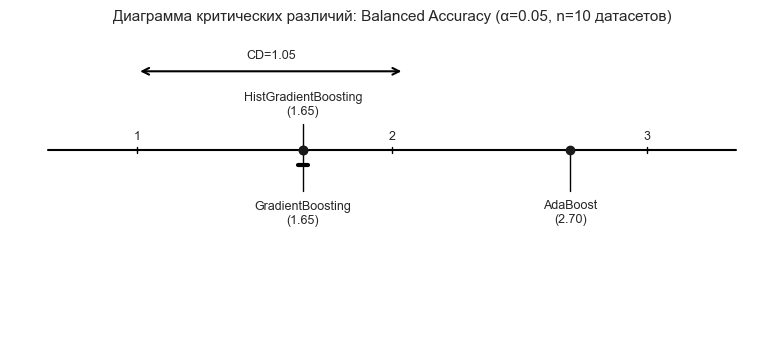

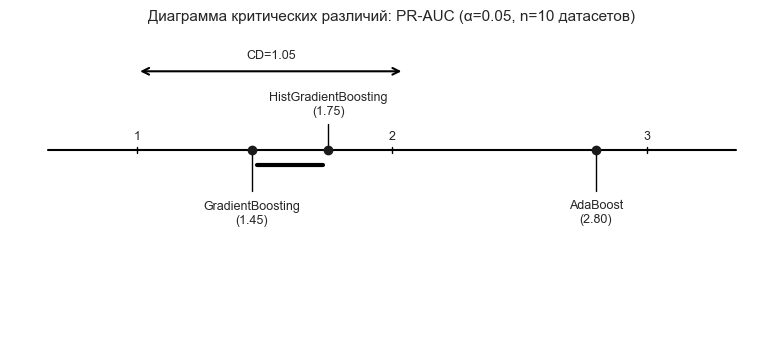

In [111]:
plot_critical_difference(
    baseline_df=baseline_df,
    metric="balanced_accuracy",
    metric_title="Balanced Accuracy",
    alpha=0.05,
    save_dir=RESULTS_DIR
)

plot_critical_difference(
    baseline_df=baseline_df,
    metric="pr_auc",
    metric_title="PR-AUC",
    alpha=0.05,
    save_dir=RESULTS_DIR
)

## Сценарий 2: Масштабируемость

In [27]:
def load_params(filepath):
    with open(filepath, "r", encoding="utf-8") as file:
        params = json.load(file)

    for dataset in params:
        for algorithm in params[dataset]:
            clean_params = {}

            for key, value in params[dataset][algorithm].items():
                clean_params[f"model__{key}"] = ast.literal_eval(value)

            params[dataset][algorithm] = clean_params

    return params

In [30]:
scale_params = load_params(RESULTS_DIR / "scenario1_best_params.json")

In [31]:
def run_scale_for_dataset(dataset_key):
    bundle = load_dataset(dataset_key)

    X_train, X_test, y_train, y_test = split_train_test(
        bundle["X"],
        bundle["y"],
        test_size=CONFIG["test_size"],
    )

    include_pr_auc = dataset_key in PR_AUC_DATASETS
    print(f"\n[scale] {dataset_key} n_train={len(X_train):,} n_test={len(X_test):,}")

    best_params_per_algo = scale_params[dataset_key]
    rows = []

    for fraction in CONFIG["scale_fractions"]:
        n_sub = max(int(len(X_train) * fraction), 50)

        if n_sub >= len(X_train):
            X_sub = X_train.reset_index(drop=True)
            y_sub = y_train.reset_index(drop=True)
        else:
            splitter = StratifiedShuffleSplit(n_splits=1, train_size=n_sub, random_state=RANDOM_STATE)

            sub_idx, _ = next(splitter.split(X_train, y_train))

            X_sub = X_train.iloc[sub_idx].reset_index(drop=True)
            y_sub = y_train.iloc[sub_idx].reset_index(drop=True)

        for algorithm in ALGORITHMS:
            params = best_params_per_algo[algorithm]

            memory_samples, (estimator, fit_time) = memory_usage(
                (
                    fit_with_params,
                    (algorithm, params, X_sub, y_sub, bundle),
                    {},
                ),
                interval=0.1,
                include_children=True,
                multiprocess=True,
                retval=True,
            )

            peak_memory_mb = max(0.0, max(memory_samples) - memory_samples[0])

            metrics = evaluate_on_test(estimator, X_test, y_test, bundle["n_classes"], include_pr_auc)

            train_metrics = evaluate_on_train(estimator, X_sub, y_sub, bundle["n_classes"], include_pr_auc)

            metrics.update(train_metrics)
            metrics["fit_time_sec"] = fit_time
            metrics["peak_memory_mb"] = peak_memory_mb

            rows.append({
                "dataset": dataset_key,
                "algorithm": ALGORITHM_LABELS[algorithm],
                "fraction": fraction,
                "n_train": len(X_sub),
                **metrics,
            })

            print(f"    frac={fraction:.2f} n={len(X_sub):>7,} {ALGORITHM_LABELS[algorithm]:<22} fit={fit_time:.2f}s mem={peak_memory_mb:.1f} МБ")

            del estimator
            gc.collect()

    return pd.DataFrame(rows)

In [32]:
SCALE_DATASETS = ["adult", "secondary_mushroom", "kick", "jannis"]

scale_dfs = []
for ds_key in SCALE_DATASETS:
    df = run_scale_for_dataset(ds_key)
    scale_dfs.append(df)


[scale] adult n_train=39,050 n_test=9,763
    frac=0.10 n=  3,905 AdaBoost               fit=1.61s mem=56.4 МБ
    frac=0.10 n=  3,905 GradientBoosting       fit=0.70s mem=56.3 МБ
    frac=0.10 n=  3,905 HistGradientBoosting   fit=0.26s mem=56.4 МБ
    frac=0.25 n=  9,762 AdaBoost               fit=3.63s mem=58.3 МБ
    frac=0.25 n=  9,762 GradientBoosting       fit=1.71s mem=55.9 МБ
    frac=0.25 n=  9,762 HistGradientBoosting   fit=0.50s mem=57.4 МБ
    frac=0.50 n= 19,525 AdaBoost               fit=7.35s mem=64.0 МБ
    frac=0.50 n= 19,525 GradientBoosting       fit=3.44s mem=57.9 МБ
    frac=0.50 n= 19,525 HistGradientBoosting   fit=0.40s mem=60.6 МБ
    frac=1.00 n= 39,050 AdaBoost               fit=14.72s mem=66.4 МБ
    frac=1.00 n= 39,050 GradientBoosting       fit=6.84s mem=61.7 МБ
    frac=1.00 n= 39,050 HistGradientBoosting   fit=0.46s mem=65.8 МБ

[scale] secondary_mushroom n_train=48,738 n_test=12,185
    frac=0.10 n=  4,873 AdaBoost               fit=2.50s mem=58.3 МБ
  

In [33]:
scale_df = pd.concat(scale_dfs, ignore_index=True)
scale_df.to_csv(RESULTS_DIR / "scenario2_scale.csv", index=False)
scale_df[['dataset', 'algorithm', 'fraction', 'fit_time_sec', 'predict_time_sec', 'peak_memory_mb']].round(4)

,dataset,algorithm,fraction,fit_time_sec,predict_time_sec,peak_memory_mb
0,adult,AdaBoost,0.10,1.6095,0.1316,56.3750
1,adult,GradientBoosting,0.10,0.7029,0.0219,56.3086
2,adult,HistGradientBoosting,0.10,0.2585,0.0293,56.3828
3,adult,AdaBoost,0.25,3.6252,0.1364,58.3398
4,adult,GradientBoosting,0.25,1.7078,0.0208,55.9141
5,adult,HistGradientBoosting,0.25,0.5025,0.0332,57.3555
6,adult,AdaBoost,0.50,7.3543,0.1298,63.9688
7,adult,GradientBoosting,0.50,3.4386,0.0204,57.8984
8,adult,HistGradientBoosting,0.50,0.3971,0.0200,60.5938
9,adult,AdaBoost,1.00,14.7207,0.1328,66.3906


In [ ]:
full_scale = scale_df[scale_df["fraction"] == 1.0]

print("СЦЕНАРИЙ 2 — ИТОГОВЫЕ МЕТРИКИ")

print("\nВремя обучения (сек) — сводка по алгоритмам:")
time_pivot = (scale_df.groupby(["algorithm", "fraction"])["fit_time_sec"].mean().unstack("fraction").round(2))
display(time_pivot)

print("\nКоэффициент ускорения HistGradientBoosting vs GradientBoosting (fit_time):")
for ds in SCALE_DATASETS:
    sub = scale_df[(scale_df["dataset"]==ds) & (scale_df["fraction"]==1.0)]
    t_gb  = sub[sub["algorithm"]=="GradientBoosting"]["fit_time_sec"].values
    t_hgb = sub[sub["algorithm"]=="HistGradientBoosting"]["fit_time_sec"].values
    if len(t_gb) and len(t_hgb) and t_hgb[0] > 0:
        print(f"  {ds}: GB={t_gb[0]:.2f}s  HistGB={t_hgb[0]:.2f}s  "
              f"speedup={t_gb[0]/t_hgb[0]:.2f}x")

print("\nПиковое потребление памяти (МБ) при 100%:")
mem_pivot = (full_scale.groupby("algorithm")["peak_memory_mb"].mean().round(1).rename("peak_memory_mb_mean").to_frame())
display(mem_pivot)

print("\nВремя предсказания (сек) при 100% обучающих данных:")
predict_time_pivot = (
    full_scale
    .groupby("algorithm")["predict_time_sec"]
    .mean()
    .round(4)
    .rename("predict_time_sec_mean")
    .to_frame()
)
predict_time_pivot

СЦЕНАРИЙ 2 — ИТОГОВЫЕ МЕТРИКИ

Время обучения (сек) — сводка по алгоритмам:


fraction,0.10,0.25,0.50,1.00
algorithm,,,,
AdaBoost,13.04,34.56,71.12,150.83
GradientBoosting,17.83,53.47,116.11,249.81
HistGradientBoosting,0.43,0.37,0.43,0.71



Коэффициент ускорения HistGradientBoosting vs GradientBoosting (fit_time):
  adult: GB=6.84s  HistGB=0.46s  speedup=14.72x
  secondary_mushroom: GB=25.39s  HistGB=0.65s  speedup=39.17x
  kick: GB=42.78s  HistGB=0.30s  speedup=143.18x
  jannis: GB=924.24s  HistGB=1.42s  speedup=649.03x

Пиковое потребление памяти (МБ) при 100%:


,peak_memory_mb_mean
algorithm,
AdaBoost,101.9
GradientBoosting,93.7
HistGradientBoosting,84.3



Время предсказания (сек) при 100% обучающих данных:


,predict_time_sec_mean
algorithm,
AdaBoost,0.4364
GradientBoosting,0.0695
HistGradientBoosting,0.0360


### Графики масштабирования

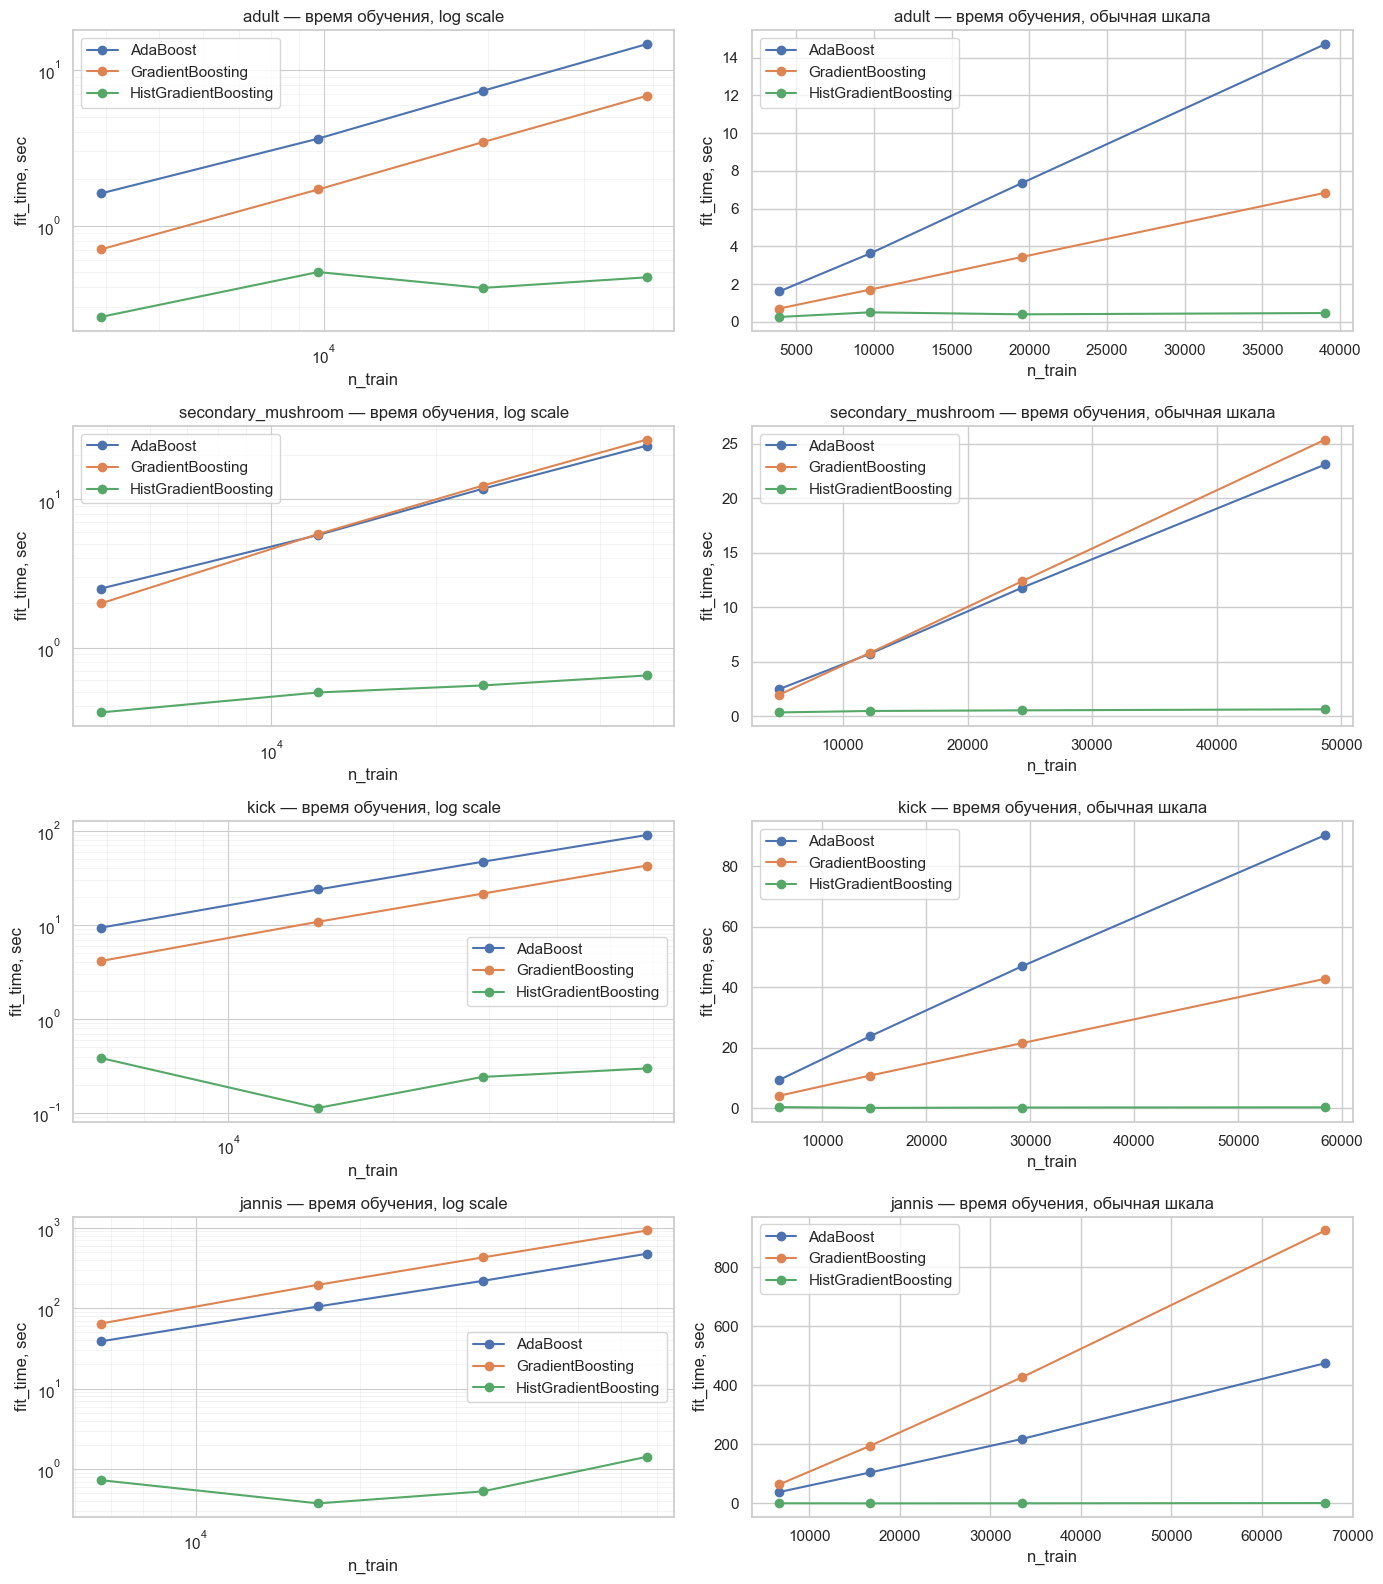

In [35]:
datasets = scale_df["dataset"].unique()

fig, axes = plt.subplots(
    len(datasets),
    2,
    figsize=(14, 4 * len(datasets)),
)

if len(datasets) == 1:
    axes = axes.reshape(1, -1)

for i, dataset in enumerate(datasets):
    sub = scale_df[scale_df["dataset"] == dataset]

    for algorithm in sub["algorithm"].unique():
        data = (
            sub[sub["algorithm"] == algorithm]
            .sort_values("n_train")
        )

        axes[i, 0].plot(
            data["n_train"],
            data["fit_time_sec"],
            marker="o",
            label=algorithm,
        )

        axes[i, 1].plot(
            data["n_train"],
            data["fit_time_sec"],
            marker="o",
            label=algorithm,
        )

    axes[i, 0].set_title(f"{dataset} — время обучения, log scale")
    axes[i, 0].set_xlabel("n_train")
    axes[i, 0].set_ylabel("fit_time, sec")
    axes[i, 0].set_xscale("log")
    axes[i, 0].set_yscale("log")
    axes[i, 0].grid(True, which="major", linewidth=0.8)
    axes[i, 0].grid(True, which="minor", linewidth=0.4, alpha=0.4)
    axes[i, 0].legend()

    axes[i, 1].set_title(f"{dataset} — время обучения, обычная шкала")
    axes[i, 1].set_xlabel("n_train")
    axes[i, 1].set_ylabel("fit_time, sec")
    axes[i, 1].grid(True)
    axes[i, 1].legend()

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "scenario2_scale_time_curves_log_and_linear.png",
    dpi=120,
    bbox_inches="tight",
)

plt.show()

## Сценарий 3: Шум в метках


In [36]:
noise_baseline_params = load_params(RESULTS_DIR / "scenario1_best_params.json")

In [37]:
def inject_label_noise(y, noise_rate, seed):
    if noise_rate <= 0:
        return y.copy()

    rng = np.random.default_rng(seed)
    y_noisy = np.array(y.values, copy=True)

    n = len(y_noisy)
    n_to_flip = int(noise_rate * n)

    flip_idx = rng.choice(n, size=n_to_flip, replace=False)
    classes = np.unique(y_noisy)

    for idx in flip_idx:
        other = classes[classes != y_noisy[idx]]
        y_noisy[idx] = rng.choice(other)

    return pd.Series(y_noisy, name=y.name)

In [38]:
def run_noise_with_params(dataset_key, best_params_per_algo):
    bundle = load_dataset(dataset_key)

    X_train, X_test, y_train, y_test = split_train_test(
        bundle["X"],
        bundle["y"],
        test_size=CONFIG["test_size"],
    )

    include_pr_auc = dataset_key in PR_AUC_DATASETS

    print(f"\n[noise] {dataset_key} n_train={len(X_train):,} n_test={len(X_test):,}")

    rows = []

    for noise_level in CONFIG["noise_levels"]:
        y_train_noisy = inject_label_noise(y_train, noise_level, seed=RANDOM_STATE + int(noise_level * 1000),)

        for algorithm in ALGORITHMS:
            params = best_params_per_algo[algorithm]

            estimator, fit_time = fit_with_params(algorithm, params, X_train, y_train_noisy, bundle)
            test_metrics = evaluate_on_test(estimator, X_test, y_test, bundle["n_classes"], include_pr_auc)
            train_noisy_metrics = evaluate_on_train(estimator, X_train, y_train_noisy, bundle["n_classes"], include_pr_auc)
            train_clean_metrics = evaluate_on_train(estimator, X_train, y_train, bundle["n_classes"], include_pr_auc)

            metrics = dict(test_metrics)

            metrics["train_noisy_balanced_accuracy"] = train_noisy_metrics["train_balanced_accuracy"]
            metrics["train_clean_balanced_accuracy"] = train_clean_metrics["train_balanced_accuracy"]
            metrics["gap_clean_train_test"] = (metrics["train_clean_balanced_accuracy"] - metrics["balanced_accuracy"])
            metrics["gap_noisy_train_test"] = (metrics["train_noisy_balanced_accuracy"] - metrics["balanced_accuracy"])
            metrics["fit_time_sec"] = fit_time

            rows.append({
                "dataset": dataset_key,
                "algorithm": ALGORITHM_LABELS[algorithm],
                "noise_level": noise_level,
                **metrics,
            })

            print(
                f"    noise={noise_level:.2f} "
                f"{ALGORITHM_LABELS[algorithm]:<22} "
                f"test BA={metrics['balanced_accuracy']:.4f} "
                f"train clean BA={metrics['train_clean_balanced_accuracy']:.4f} "
                f"train noisy BA={metrics['train_noisy_balanced_accuracy']:.4f} "
                f"gap clean={metrics['gap_clean_train_test']:.4f}"
            )

            del estimator
            gc.collect()

    return pd.DataFrame(rows)

In [39]:
NOISE_DATASETS = ["digits", "spambase", "phoneme"]

noise_dfs = []

for ds_key in NOISE_DATASETS:
    params = noise_baseline_params[ds_key]

    df = run_noise_with_params(ds_key, params)
    noise_dfs.append(df)

noise_df = pd.concat(noise_dfs, ignore_index=True)


[noise] digits n_train=4,496 n_test=1,124
    noise=0.00 AdaBoost               test BA=0.9635 train clean BA=0.9945 train noisy BA=0.9945 gap clean=0.0310
    noise=0.00 GradientBoosting       test BA=0.9813 train clean BA=1.0000 train noisy BA=1.0000 gap clean=0.0187
    noise=0.00 HistGradientBoosting   test BA=0.9786 train clean BA=1.0000 train noisy BA=1.0000 gap clean=0.0214
    noise=0.05 AdaBoost               test BA=0.9511 train clean BA=0.9698 train noisy BA=0.9356 gap clean=0.0187
    noise=0.05 GradientBoosting       test BA=0.9777 train clean BA=0.9521 train noisy BA=0.9980 gap clean=-0.0256
    noise=0.05 HistGradientBoosting   test BA=0.9715 train clean BA=0.9837 train noisy BA=0.9666 gap clean=0.0123
    noise=0.10 AdaBoost               test BA=0.9245 train clean BA=0.9559 train noisy BA=0.8773 gap clean=0.0315
    noise=0.10 GradientBoosting       test BA=0.9698 train clean BA=0.9450 train noisy BA=0.9549 gap clean=-0.0247
    noise=0.10 HistGradientBoosting   test 

In [ ]:
noise_df.to_csv(RESULTS_DIR / "scenario3_noise.csv", index=False)
noise_df.round(4)

,dataset,algorithm,noise_level,balanced_accuracy,f1_macro,roc_auc,pr_auc,log_loss,predict_time_sec,train_noisy_balanced_accuracy,train_clean_balanced_accuracy,gap_clean_train_test,gap_noisy_train_test,fit_time_sec
0,digits,AdaBoost,0.00,0.9635,0.9639,0.9975,0.9863,2.2734,0.0420,0.9945,0.9945,0.0310,0.0310,4.2167
1,digits,GradientBoosting,0.00,0.9813,0.9813,0.9998,0.9984,0.0588,0.0120,1.0000,1.0000,0.0187,0.0187,11.3448
2,digits,HistGradientBoosting,0.00,0.9786,0.9787,0.9997,0.9980,0.0631,0.0251,1.0000,1.0000,0.0214,0.0214,0.8744
3,digits,AdaBoost,0.05,0.9511,0.9514,0.9942,0.9645,2.2901,0.0418,0.9356,0.9698,0.0187,-0.0155,4.1311
4,digits,GradientBoosting,0.05,0.9777,0.9778,0.9993,0.9967,0.1062,0.0121,0.9980,0.9521,-0.0256,0.0203,11.4735
5,digits,HistGradientBoosting,0.05,0.9715,0.9716,0.9994,0.9959,0.1302,0.0234,0.9666,0.9837,0.0123,-0.0049,0.8975
6,digits,AdaBoost,0.10,0.9245,0.9249,0.9916,0.9569,2.2930,0.0437,0.8773,0.9559,0.0315,-0.0472,4.1214
7,digits,GradientBoosting,0.10,0.9698,0.9698,0.9991,0.9937,0.1915,0.0120,0.9549,0.9450,-0.0247,-0.0149,11.4374
8,digits,HistGradientBoosting,0.10,0.9742,0.9741,0.9994,0.9954,0.1976,0.0263,0.9188,0.9787,0.0044,-0.0554,0.8831
9,digits,AdaBoost,0.20,0.9065,0.9075,0.9897,0.9428,2.2944,0.0388,0.7673,0.9398,0.0333,-0.1391,4.1660


In [41]:
print("СЦЕНАРИЙ 3 — ИТОГОВЫЕ МЕТРИКИ")

print("\nСредняя Balanced Accuracy по алгоритмам при каждом уровне шума:")
noise_agg = (noise_df.groupby(["algorithm", "noise_level"])["balanced_accuracy"].mean().unstack("noise_level").round(4))
display(noise_agg)

noise_agg.to_csv(RESULTS_DIR / "scenario3_noise_balanced_accuracy_by_noise.csv")

print("\nПадение Balanced Accuracy от 0% до 20% шума:")

rows_deg = []

for algo in noise_df["algorithm"].unique():
    for ds in noise_df["dataset"].unique():
        sub = noise_df[(noise_df["algorithm"] == algo) & (noise_df["dataset"] == ds)]

        ba0 = sub[sub["noise_level"] == 0.00]["balanced_accuracy"].values
        ba20 = sub[sub["noise_level"] == 0.20]["balanced_accuracy"].values

        if len(ba0) and len(ba20):
            rows_deg.append({
                "algorithm": algo,
                "dataset": ds,
                "BA_0pct": ba0[0],
                "BA_20pct": ba20[0],
                "delta_BA": ba0[0] - ba20[0],
            })

deg_df = pd.DataFrame(rows_deg)

pivot_deg = (deg_df.pivot(index="dataset", columns="algorithm", values="delta_BA").round(4))
display(pivot_deg)

pivot_deg.to_csv(RESULTS_DIR / "scenario3_noise_delta_ba.csv")

print("\nСреднее падение BA, чем меньше — тем устойчивее:")
mean_delta = (pivot_deg.mean().sort_values().rename("mean_delta_BA").to_frame())
display(mean_delta)

mean_delta.to_csv(RESULTS_DIR / "scenario3_noise_mean_delta_ba.csv")

СЦЕНАРИЙ 3 — ИТОГОВЫЕ МЕТРИКИ

Средняя Balanced Accuracy по алгоритмам при каждом уровне шума:


noise_level,0.00,0.05,0.10,0.20
algorithm,,,,
AdaBoost,0.9121,0.8949,0.8863,0.8656
GradientBoosting,0.9180,0.9159,0.9096,0.8910
HistGradientBoosting,0.9183,0.9089,0.9111,0.8912



Падение Balanced Accuracy от 0% до 20% шума:


algorithm,AdaBoost,GradientBoosting,HistGradientBoosting
dataset,,,
digits,0.0570,0.0240,0.0116
phoneme,0.0350,0.0352,0.0430
spambase,0.0475,0.0217,0.0267



Среднее падение BA, чем меньше — тем устойчивее:


,mean_delta_BA
algorithm,
GradientBoosting,0.026967
HistGradientBoosting,0.027100
AdaBoost,0.046500


### Графики деградации качества

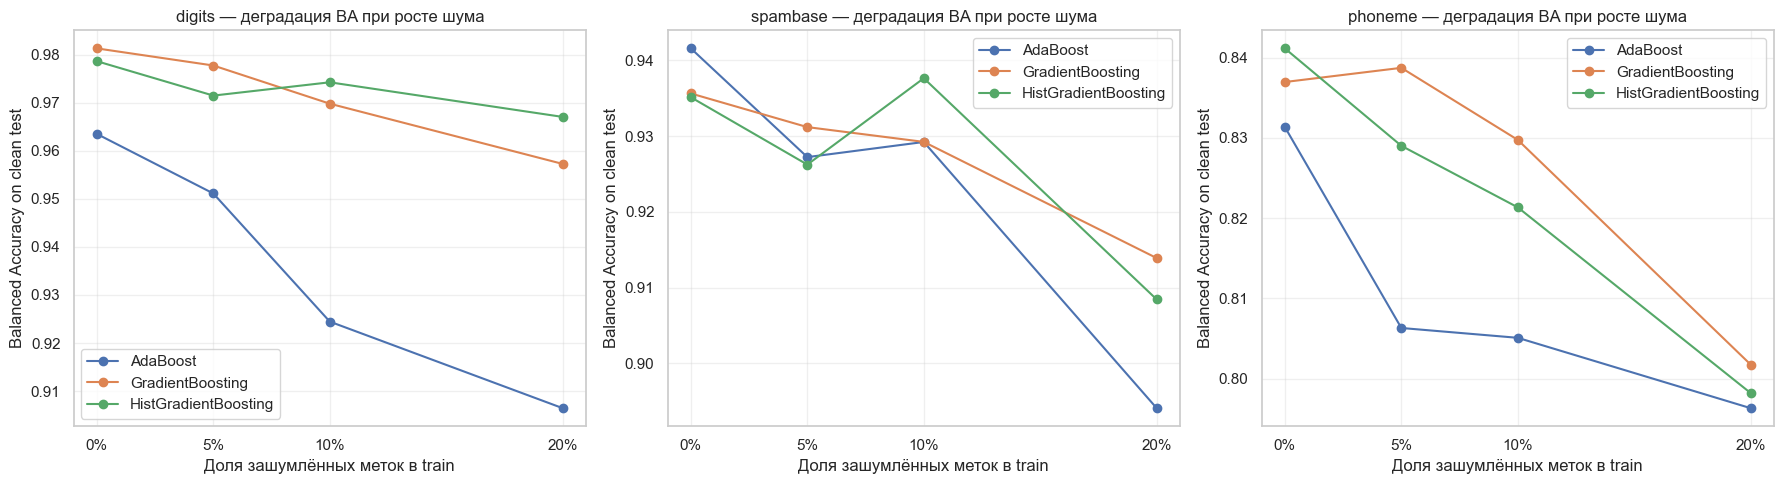

In [ ]:
datasets = noise_df["dataset"].unique()

fig, axes = plt.subplots(
    1,
    len(datasets),
    figsize=(6 * len(datasets), 5),
)

if len(datasets) == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    sub = noise_df[noise_df["dataset"] == dataset]
    noise_levels = sorted(sub["noise_level"].unique())

    for algorithm in sub["algorithm"].unique():
        data = sub[sub["algorithm"] == algorithm].sort_values("noise_level")

        ax.plot(data["noise_level"], data["balanced_accuracy"], marker="o", label=algorithm)

    ax.set_title(f"{dataset} — деградация BA при росте шума")
    ax.set_xlabel("Доля зашумлённых меток в train")
    ax.set_ylabel("Balanced Accuracy on clean test")
    ax.set_xticks(noise_levels)
    ax.xaxis.set_major_formatter(
        mtick.PercentFormatter(xmax=1.0, decimals=0)
    )
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "scenario3_noise_curves.png", dpi=120, bbox_inches="tight")

plt.show()

## Сценарий 4: Дисбаланс

In [43]:
baseline_df = pd.read_csv(RESULTS_DIR / "scenario1_baseline.csv")

LABEL_TO_ALGO = {v: k for k, v in ALGORITHM_LABELS.items()}

baseline_disbalance_results = {}

for _, row in baseline_df.iterrows():
    ds_key = row["dataset"]
    algo_label = row["algorithm"]
    algo_key = LABEL_TO_ALGO[algo_label]

    metrics = row.drop(["dataset", "algorithm"]).to_dict()

    baseline_disbalance_results.setdefault(ds_key, {})[algo_key] = metrics

In [44]:
def run_imbalance_natural():
    natural_keys = ["adult", "kick", "jannis"]
    rows = []
    for ds_key in natural_keys:
        for algo, m in baseline_disbalance_results[ds_key].items():
            row = {
                "dataset": ds_key,
                "algorithm": ALGORITHM_LABELS[algo],
                "kind": "natural",
                **{k: v for k, v in m.items() if k != "best_params"},
            }
            rows.append(row)
    return pd.DataFrame(rows)


In [45]:
imb_natural_df = run_imbalance_natural()
imb_natural_df.to_csv(RESULTS_DIR / "scenario4a_imbalance_natural.csv", index=False)

print("Естественный дисбаланс:")
imb_natural_df[['dataset', 'algorithm', 'kind', 'train_balanced_accuracy', 'balanced_accuracy', 'pr_auc']].round(4)

Естественный дисбаланс:


,dataset,algorithm,kind,train_balanced_accuracy,balanced_accuracy,pr_auc
0,adult,AdaBoost,natural,0.8369,0.8357,0.8139
1,adult,GradientBoosting,natural,0.8572,0.8426,0.8288
2,adult,HistGradientBoosting,natural,0.8650,0.8410,0.8323
3,kick,AdaBoost,natural,0.6577,0.6391,0.2522
4,kick,GradientBoosting,natural,0.7297,0.6627,0.2873
5,kick,HistGradientBoosting,natural,0.7578,0.6919,0.4681
6,jannis,AdaBoost,natural,0.6173,0.5911,0.5078
7,jannis,GradientBoosting,natural,0.7500,0.6431,0.6062
8,jannis,HistGradientBoosting,natural,0.7515,0.6457,0.6044


In [ ]:
ARTIFICIAL_IMBALANCE_PARAM_GRIDS = {
    "adult": {
        "90_10": {
            "adaboost": { 
                "model__n_estimators": [200, 400, 600],
                "model__learning_rate": [0.03, 0.05, 0.1],
                "model__estimator__max_depth": [1, 2, 3],
                "model__estimator__min_samples_leaf": [50, 100, 200],
            },

            "gradient_boosting": {
                "model__n_estimators": [100, 200, 300],
                "model__learning_rate": [0.03, 0.05, 0.1],
                "model__max_depth": [3, 5],
                "model__min_samples_leaf": [50, 100, 200],
                "model__subsample": [0.8],
            },

            "hist_gradient_boosting": {
                "model__max_iter": [200, 300],
                "model__learning_rate": [0.03, 0.05, 0.1],
                "model__max_depth": [5, 7],
                "model__min_samples_leaf": [50, 100, 200],
                "model__l2_regularization": [1.0, 10.0],
            },
        },

        "95_5": {
            "adaboost": {
                "model__n_estimators": [200, 400, 600],
                "model__learning_rate": [0.03, 0.05, 0.1],
                "model__estimator__max_depth": [1, 2, 3],
                "model__estimator__min_samples_leaf": [20, 50, 100],
            },

            "gradient_boosting": {
                "model__n_estimators": [100, 200, 300],
                "model__learning_rate": [0.03, 0.05, 0.1],
                "model__max_depth": [3, 5],
                "model__min_samples_leaf": [20, 50, 100],
                "model__subsample": [0.8],
            },

            "hist_gradient_boosting": {
                "model__max_iter": [200, 300],
                "model__learning_rate": [0.03, 0.05, 0.1],
                "model__max_depth": [5, 7],
                "model__min_samples_leaf": [20, 50, 100],
                "model__l2_regularization": [1.0, 10.0],
            },
        },

        "99_1": {
            "adaboost": {
                "model__n_estimators": [200, 400, 600],
                "model__learning_rate": [0.03, 0.05, 0.1],
                "model__estimator__max_depth": [1, 2, 3],
                "model__estimator__min_samples_leaf": [5, 10, 20],
            },

            "gradient_boosting": {
                "model__n_estimators": [100, 200, 300],
                "model__learning_rate": [0.03, 0.05, 0.075],
                "model__max_depth": [2, 3, 4],
                "model__min_samples_leaf": [5, 10, 20],
                "model__subsample": [0.8],
            },

            "hist_gradient_boosting": {
                "model__max_iter": [50, 100],
                "model__learning_rate": [0.01, 0.03],
                "model__max_depth": [1, 2],
                "model__min_samples_leaf": [10, 20, 30],
                "model__l2_regularization": [50.0, 100.0],
            },
        },
    },

    "spambase": {
        "90_10": {
            "adaboost": {
                "model__n_estimators": [100, 200],
                "model__learning_rate": [0.03, 0.05, 0.1],
                "model__estimator__max_depth": [1, 2, 3],
                "model__estimator__min_samples_leaf": [5, 10, 20],
            },

            "gradient_boosting": {
                "model__n_estimators": [100, 150, 200],
                "model__learning_rate": [0.03, 0.05, 0.075],
                "model__max_depth": [2, 3],
                "model__min_samples_leaf": [5, 10, 20],
                "model__subsample": [0.8],
            },

            "hist_gradient_boosting": {
                "model__max_iter": [100, 200],
                "model__learning_rate": [0.03, 0.05, 0.075],
                "model__max_depth": [2, 3],
                "model__min_samples_leaf": [5, 10, 20],
                "model__l2_regularization": [1.0, 10.0],
            },
        },

        "95_5": {
            "adaboost": {
                "model__n_estimators": [50, 100],
                "model__learning_rate": [0.01, 0.03],
                "model__estimator__max_depth": [1, 2],
                "model__estimator__min_samples_leaf": [5, 10, 15],
            },

            "gradient_boosting": {
                "model__n_estimators": [50, 100],
                "model__learning_rate": [0.01, 0.03],
                "model__max_depth": [1, 2],
                "model__min_samples_leaf": [5, 10, 15],
                "model__subsample": [0.6, 0.8],
            },

            "hist_gradient_boosting": {
                "model__max_iter": [50, 100],
                "model__learning_rate": [0.01, 0.03],
                "model__max_depth": [1, 2],
                "model__min_samples_leaf": [1, 5, 10, 15],
                "model__l2_regularization": [1.0, 10.0],
            },
        },

        "99_1": {
            "adaboost": {
                "model__n_estimators": [50, 75, 100],
                "model__learning_rate": [0.03, 0.05, 0.75],
                "model__estimator__max_depth": [1, 2],
                "model__estimator__min_samples_leaf": [1, 3, 5],
            },

            "gradient_boosting": {
                "model__n_estimators": [50, 100, 150],
                "model__learning_rate": [0.01, 0.03, 0.05],
                "model__max_depth": [1, 2],
                "model__min_samples_leaf": [1, 3, 5],
                "model__subsample": [0.8],
            },

            "hist_gradient_boosting": {
                "model__max_iter": [50, 100],
                "model__learning_rate": [0.01, 0.03, 0.05],
                "model__max_depth": [1, 2],
                "model__min_samples_leaf": [1, 2, 3],
                "model__l2_regularization": [10.0, 30.0],
            },
        },
    },
}

In [47]:
def ratio_key(ratio):
    return f"{ratio[0]}_{ratio[1]}"

In [48]:
def downsample_to_ratio(X, y, target_ratio):
    classes, counts = np.unique(y, return_counts=True)

    if counts[0] >= counts[1]:
        maj_cls, min_cls = classes[0], classes[1]
        maj_count, min_count = counts[0], counts[1]
    else:
        maj_cls, min_cls = classes[1], classes[0]
        maj_count, min_count = counts[1], counts[0]

    maj_pct, min_pct = target_ratio
    target_min_count = int(maj_count * min_pct / maj_pct)
    target_min_count = max(min(target_min_count, min_count), 5)

    rng = np.random.default_rng(RANDOM_STATE)
    min_indices = np.where(y.values == min_cls)[0]
    keep_min = rng.choice(min_indices, size=target_min_count, replace=False)
    maj_indices = np.where(y.values == maj_cls)[0]

    keep_idx = np.sort(np.concatenate([maj_indices, keep_min]))
    return X.iloc[keep_idx].reset_index(drop=True), y.iloc[keep_idx].reset_index(drop=True)


In [49]:
def run_imbalance_artificial_for_dataset(dataset_key):
    bundle_full = load_dataset(dataset_key)

    print(f"\n[imb-4B] {dataset_key}")

    rows = []

    for ratio in CONFIG["imbalance_ratios"]:
        ratio_str = f"{ratio[0]}:{ratio[1]}"
        rkey = ratio_key(ratio)

        X_ratio, y_ratio = downsample_to_ratio(bundle_full["X"], bundle_full["y"], ratio,)
        X_train, X_test, y_train, y_test = split_train_test(X_ratio, y_ratio, test_size=CONFIG["test_size"],)

        train_counts = pd.Series(y_train).value_counts()
        test_counts = pd.Series(y_test).value_counts()

        minority_train = int(train_counts.min())
        minority_test = int(test_counts.min())

        size_group = dataset_size_group(len(X_train))
        bundle_ratio = {**bundle_full, "X": X_train, "y": y_train, "n_samples": len(X_train), "size_group": size_group,}
        ratio_grid = ARTIFICIAL_IMBALANCE_PARAM_GRIDS[dataset_key][rkey]
        custom_param_grids = {"custom": ratio_grid}

        print(
            f"\n  [{ratio_str}] "
            f"n_total={len(X_ratio):,} "
            f"n_train={len(X_train):,} "
            f"n_test={len(X_test):,} "
            f"minority_train={minority_train} "
            f"minority_test={minority_test} "
            f"group={size_group}"
        )

        for algorithm in ALGORITHMS:
            search = tune_hyperparameters(
                algorithm,
                X_train,
                y_train,
                bundle_ratio,
                size_group_override="custom",
                param_grids=custom_param_grids,
            )

            best_params = search.best_params_

            estimator, fit_time = fit_with_params(algorithm, best_params, X_train, y_train, bundle_ratio)
            metrics = evaluate_on_test(estimator, X_test, y_test, n_classes=2, include_pr_auc=True)
            train_metrics = evaluate_on_train(estimator, X_train, y_train, n_classes=2, include_pr_auc=True,)
            metrics.update(train_metrics)

            metrics["fit_time_sec"] = fit_time

            rows.append({
                "dataset": dataset_key,
                "algorithm": ALGORITHM_LABELS[algorithm],
                "kind": "artificial",
                "ratio": ratio_str,
                **metrics,
            })

            print(
                f"  {ALGORITHM_LABELS[algorithm]:<22} "
                f"test PR-AUC={metrics.get('pr_auc', float('nan')):.4f} "
                f"train PR-AUC={metrics.get('train_pr_auc', float('nan')):.4f} "
                f"test BA={metrics['balanced_accuracy']:.4f} "
                f"train BA={metrics['train_balanced_accuracy']:.4f} "
                f"fit={fit_time:.2f}s"
            )

            del estimator
            gc.collect()

    return pd.DataFrame(rows)

In [50]:
ARTIFICIAL_IMB_DATASETS = ["spambase", "adult"]

artificial_dfs = []

for ds_key in ARTIFICIAL_IMB_DATASETS:
    df = run_imbalance_artificial_for_dataset(ds_key)
    artificial_dfs.append(df)


[imb-4B] spambase

  [90:10] n_total=2,812 n_train=2,249 n_test=563 minority_train=225 minority_test=56 group=medium
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  AdaBoost               test PR-AUC=0.8912 train PR-AUC=0.9491 test BA=0.9397 train BA=0.9580 fit=0.45s
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  GradientBoosting       test PR-AUC=0.9217 train PR-AUC=0.9621 test BA=0.9565 train BA=0.9768 fit=0.70s
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  HistGradientBoosting   test PR-AUC=0.9014 train PR-AUC=0.9626 test BA=0.9585 train BA=0.9676 fit=0.09s

  [95:5] n_total=2,664 n_train=2,131 n_test=533 minority_train=106 minority_test=27 group=medium
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  AdaBoost               test PR-AUC=0.6694 train PR-AUC=0.8388 test BA=0.9118 train BA=0.9378 fit=0.31s
Fitting 5 folds for each of 48 candidates, totalling 240 fits
  GradientBoosting       test PR-AUC=0.7046 train PR-A

In [ ]:
imb_artificial_df = pd.concat(artificial_dfs, ignore_index=True)

imb_artificial_df.to_csv(RESULTS_DIR / "scenario4b_imbalance_artificial.csv", index=False)
imb_artificial_df = pd.read_csv(RESULTS_DIR / 'scenario4b_imbalance_artificial.csv')
imb_artificial_df[['dataset', 'algorithm', 'ratio', 'train_balanced_accuracy', 'balanced_accuracy', 'train_pr_auc', 'pr_auc']].round(4)

,dataset,algorithm,ratio,train_balanced_accuracy,balanced_accuracy,train_pr_auc,pr_auc
0,spambase,AdaBoost,90:10,0.9580,0.9397,0.9491,0.8912
1,spambase,GradientBoosting,90:10,0.9768,0.9565,0.9621,0.9217
2,spambase,HistGradientBoosting,90:10,0.9676,0.9585,0.9626,0.9014
3,spambase,AdaBoost,95:5,0.9378,0.9118,0.8388,0.6694
4,spambase,GradientBoosting,95:5,0.9495,0.9002,0.8690,0.7046
5,spambase,HistGradientBoosting,95:5,0.9455,0.8963,0.8407,0.6694
6,spambase,AdaBoost,99:1,0.9354,0.9832,0.4811,0.4025
7,spambase,GradientBoosting,99:1,0.9285,0.9675,0.5125,0.3800
8,spambase,HistGradientBoosting,99:1,0.9125,0.9507,0.4043,0.3919
9,adult,AdaBoost,90:10,0.8301,0.8361,0.6534,0.6640


In [ ]:
print("СЦЕНАРИЙ 4 — ИТОГОВЫЕ МЕТРИКИ")

imb_artificial_eval = imb_artificial_df.copy()

if "pr_auc" in imb_artificial_eval.columns:
    print("\n4B. PR-AUC по соотношениям, среднее по датасетам:")
    piv_4b_pr = (imb_artificial_eval.groupby(["ratio", "algorithm"])["pr_auc"].mean().unstack("algorithm").round(4))
display(piv_4b_pr)

print("\n4B. Balanced Accuracy по соотношениям, среднее по датасетам:")
piv_4b_ba = (imb_artificial_eval.groupby(["ratio", "algorithm"])["balanced_accuracy"].mean().unstack("algorithm").round(4))
display(piv_4b_ba)

if "pr_auc" in imb_artificial_eval.columns:
    print("\nПадение PR-AUC от 90:10 до 99:1, среднее по датасетам:")
    
    pr_90 = (imb_artificial_eval[imb_artificial_eval["ratio"] == "90:10"].groupby("algorithm")["pr_auc"].mean())
    pr_99 = (imb_artificial_eval[imb_artificial_eval["ratio"] == "99:1"].groupby("algorithm")["pr_auc"].mean())
    
    delta_pr = ((pr_90 - pr_99).round(4).rename("delta_PR_AUC_90_to_99").to_frame().sort_values("delta_PR_AUC_90_to_99"))

    display(delta_pr)

СЦЕНАРИЙ 4 — ИТОГОВЫЕ МЕТРИКИ

4B. PR-AUC по соотношениям, среднее по датасетам:


algorithm,AdaBoost,GradientBoosting,HistGradientBoosting
ratio,,,
90:10,0.7776,0.8062,0.7967
95:5,0.6194,0.6481,0.6366
99:1,0.3217,0.2879,0.2917



4B. Balanced Accuracy по соотношениям, среднее по датасетам:


algorithm,AdaBoost,GradientBoosting,HistGradientBoosting
ratio,,,
90:10,0.8879,0.8994,0.9010
95:5,0.8742,0.8701,0.8672
99:1,0.8936,0.8850,0.8840



Падение PR-AUC от 90:10 до 99:1, среднее по датасетам:


,delta_PR_AUC_90_to_99
algorithm,
AdaBoost,0.4559
HistGradientBoosting,0.5050
GradientBoosting,0.5183


### Графики динамики PR-AUC при росте дисбаланса

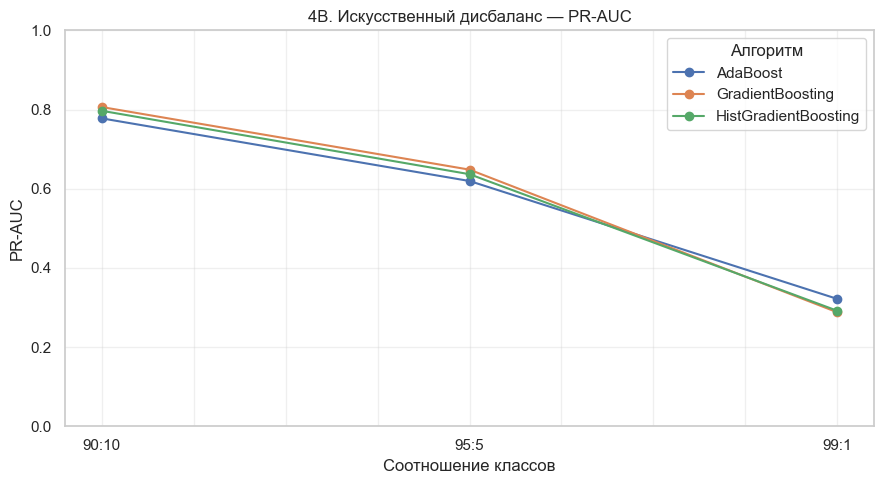

In [53]:
ratio_order = ["90:10", "95:5", "99:1"]

imb_artificial_eval = imb_artificial_df.copy()

piv_4b_pr = (
imb_artificial_eval
    .groupby(["ratio", "algorithm"])["pr_auc"]
    .mean()
    .unstack("algorithm")
    .reindex(ratio_order)
    .round(4)
)

ax = piv_4b_pr.plot(marker="o", figsize=(9, 5))
ax.set_title("4B. Искусственный дисбаланс — PR-AUC")
ax.set_xlabel("Соотношение классов")
ax.set_ylabel("PR-AUC")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(title="Алгоритм")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "scenario4b_artificial_pr_auc_by_ratio.png",
    dpi=120,
    bbox_inches="tight"
)
plt.show()

## Сценарий 5: Структура признаков и сложность задачи

In [54]:
complexity_baseline = pd.read_csv(RESULTS_DIR / "scenario1_baseline.csv")

In [55]:
def run_complexity_5a():
    """Сводка из baseline DataFrame для датасетов разной размерности."""
    
    keys = ["phoneme", "digits", "spambase", "jannis"]
    rows = []

    for ds_key in keys:
        sub = complexity_baseline[
            complexity_baseline["dataset"] == ds_key
        ]

        n_features = load_dataset(ds_key)["n_features"]

        for _, row in sub.iterrows():
            row_dict = row.to_dict()
            row_dict["n_features"] = n_features
            row_dict["kind"] = "original"
            rows.append(row_dict)

    return pd.DataFrame(rows)

In [56]:
complexity_5a_df = run_complexity_5a()

In [57]:
complexity_5a_df.to_csv(RESULTS_DIR / "scenario5a_complexity_dimension.csv", index=False)

print("Зависимость от размерности:")
complexity_5a_df[['dataset', 'algorithm', 'balanced_accuracy', 'f1_macro', 'roc_auc', 'pr_auc', 'log_loss']].round(4)

Зависимость от размерности:


,dataset,algorithm,balanced_accuracy,f1_macro,roc_auc,pr_auc,log_loss
0,phoneme,AdaBoost,0.8314,0.8063,0.8939,0.7731,0.5337
1,phoneme,GradientBoosting,0.8370,0.8151,0.9064,0.7885,0.3747
2,phoneme,HistGradientBoosting,0.8412,0.8127,0.9022,0.7787,0.3874
3,digits,AdaBoost,0.9635,0.9639,0.9975,0.9863,2.2734
4,digits,GradientBoosting,0.9813,0.9813,0.9998,0.9984,0.0588
5,digits,HistGradientBoosting,0.9786,0.9787,0.9997,0.9980,0.0631
6,spambase,AdaBoost,0.9416,0.9396,0.9871,0.9780,0.5025
7,spambase,GradientBoosting,0.9356,0.9345,0.9860,0.9722,0.1538
8,spambase,HistGradientBoosting,0.9351,0.9345,0.9863,0.9726,0.1550
9,jannis,AdaBoost,0.5911,0.4964,0.8008,0.5078,1.3595


In [58]:
def run_complexity_5b_noise_features():

    bundle = load_dataset("spambase")
    X_orig = bundle["X"]
    y = bundle["y"]

    n_extra = CONFIG["n_noise_features"]

    rng = np.random.default_rng(RANDOM_STATE)

    noise = pd.DataFrame(
        rng.uniform(0, 1, size=(len(X_orig), n_extra)),
        columns=[f"noise_feat_{i}" for i in range(n_extra)],
        index=X_orig.index,
    )

    X_aug = pd.concat([X_orig, noise], axis=1)

    bundle_aug = dict(bundle)
    bundle_aug["X"] = X_aug
    bundle_aug["numeric_cols"] = bundle["numeric_cols"] + list(noise.columns)
    bundle_aug["n_features"] = X_aug.shape[1]

    bundle_aug["size_group"] = "medium"

    X_tr, X_te, y_tr, y_te = split_train_test(X_aug, y, test_size=CONFIG["test_size"])

    print(
        f"\n[complex-5B] spambase + {n_extra} шумовых признаков  "
        f"n={len(X_aug):,}  group={bundle_aug['size_group']}  "
        f"features={X_aug.shape[1]}  train={len(X_tr):,}  test={len(X_te):,}"
    )

    include_pr_auc = True

    results = {}
    best_params_per_algo = {}
    cv_results_per_algo = {}

    for algo in ALGORITHMS:
        t0 = time.perf_counter()
        search = tune_hyperparameters(algo, X_tr, y_tr, bundle_aug)
        tune_time = time.perf_counter() - t0
        
        best_estimator = search.best_estimator_
        best_params = search.best_params_

        _, fit_time = fit_with_params(algo, best_params, X_tr, y_tr, bundle_aug)
        metrics = evaluate_on_test(best_estimator, X_te, y_te, bundle_aug["n_classes"], include_pr_auc)
        train_metrics = evaluate_on_train(best_estimator, X_tr, y_tr, bundle_aug["n_classes"], include_pr_auc)
        metrics.update(train_metrics)

        metrics["fit_time_sec"] = fit_time
        metrics["tune_time_sec"] = tune_time
        metrics["best_params"] = {k.replace("model__", ""): v for k, v in best_params.items()}

        results[algo] = metrics
        best_params_per_algo[algo] = best_params
        cv_results_per_algo[algo] = pd.DataFrame(search.cv_results_)

        pr_str = f"  PR={metrics['pr_auc']:.4f}" if "pr_auc" in metrics else ""

        print(
            f"  {ALGORITHM_LABELS[algo]:<22}  "
            f"test BA={metrics['balanced_accuracy']:.4f}  "
            f"train BA={metrics.get('train_balanced_accuracy', float('nan')):.4f}  "
            f"ROC={metrics.get('roc_auc', float('nan')):.4f}"
            f"{pr_str}  "
            f"fit={fit_time:.2f}s  "
            f"tune={tune_time:.2f}s"
        )

    gc.collect()

    return results

In [59]:
complexity_5b_df = run_complexity_5b_noise_features()


[complex-5B] spambase + 50 шумовых признаков  n=4,210  group=medium  features=107  train=3,368  test=842
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  AdaBoost                test BA=0.9381  train BA=0.9586  ROC=0.9848  PR=0.9751  fit=7.45s  tune=56.23s
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  GradientBoosting        test BA=0.9356  train BA=0.9485  ROC=0.9843  PR=0.9761  fit=2.46s  tune=33.17s
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  HistGradientBoosting    test BA=0.9346  train BA=0.9573  ROC=0.9848  PR=0.9694  fit=0.14s  tune=3.05s


In [ ]:
rows = []

for algo, metrics in complexity_5b_df.items():
    row = {
        "dataset": "spambase_with_noise_features",
        "algorithm": ALGORITHM_LABELS[algo],
        "n_features": 107,
        "kind": "with_noise_features",
    }

    row.update({k: v for k, v in metrics.items() if k != "best_params"})
    rows.append(row)

complexity_5b_df = pd.DataFrame(rows)
complexity_5b_df.to_csv(RESULTS_DIR / "scenario5b_noise_features.csv", index=False)

print("\nВлияние шумовых признаков:")
display(complexity_5b_df[['algorithm', 'train_balanced_accuracy', 'balanced_accuracy', 'f1_macro', 'roc_auc', 'pr_auc', 'log_loss']].round(4))


Влияние шумовых признаков:


,algorithm,train_balanced_accuracy,balanced_accuracy,f1_macro,roc_auc,pr_auc,log_loss
0,AdaBoost,0.9586,0.9381,0.9370,0.9848,0.9751,0.5119
1,GradientBoosting,0.9485,0.9356,0.9335,0.9843,0.9761,0.1743
2,HistGradientBoosting,0.9573,0.9346,0.9333,0.9848,0.9694,0.1662


### Сравнение Spambase: исходный vs. +50 шумовых признаков

,algorithm,BA_original,BA_with_noise
0,AdaBoost,0.9416,0.9381
1,GradientBoosting,0.9356,0.9356
2,HistGradientBoosting,0.9351,0.9346


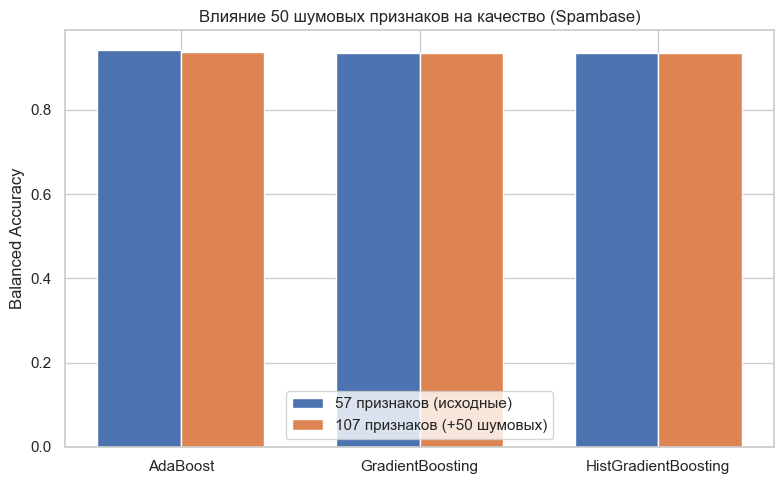

In [61]:
def plot_complexity_comparison():
    """Сравниваем BA на Spambase (оригинал из baseline) vs. Spambase+noise (5B)."""
    spambase_orig = complexity_5a_df[complexity_5a_df["dataset"] == "spambase"][
        ["algorithm", "balanced_accuracy"]
    ].rename(columns={"balanced_accuracy": "BA_original"})

    spambase_aug = complexity_5b_df[
        complexity_5b_df["dataset"] == "spambase_with_noise_features"
    ][["algorithm", "balanced_accuracy"]].rename(columns={"balanced_accuracy": "BA_with_noise"})

    merged = spambase_orig.merge(spambase_aug, on="algorithm")
    display(merged.round(4))

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(merged))
    w = 0.35
    ax.bar(x - w/2, merged["BA_original"], w, label="57 признаков (исходные)")
    ax.bar(x + w/2, merged["BA_with_noise"], w, label="107 признаков (+50 шумовых)")
    ax.set_xticks(x); ax.set_xticklabels(merged["algorithm"])
    ax.set_ylabel("Balanced Accuracy")
    ax.set_title("Влияние 50 шумовых признаков на качество (Spambase)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "scenario5_noise_features_comparison.png", dpi=120, bbox_inches="tight")
    plt.show()


plot_complexity_comparison()

In [ ]:
print("СЦЕНАРИЙ 5 — ИТОГОВЫЕ МЕТРИКИ")

print("\nBalanced Accuracy по датасетам:")
piv_5a = (complexity_5a_df.sort_values("n_features")
          .pivot(index="dataset", columns="algorithm", values="balanced_accuracy")
          .round(4))
display(piv_5a)


print("\nВлияние 50 шумовых признаков — изменение Balanced Accuracy:")
spambase_orig = complexity_5a_df[complexity_5a_df["dataset"]=="spambase"][["algorithm","balanced_accuracy"]].rename(columns={"balanced_accuracy":"BA_original"})
spambase_aug  = complexity_5b_df[["algorithm","balanced_accuracy"]].rename(columns={"balanced_accuracy":"BA_with_noise"})

merged_5b = spambase_orig.merge(spambase_aug, on="algorithm")
merged_5b["delta_BA"] = (merged_5b["BA_original"] - merged_5b["BA_with_noise"]).round(4)
merged_5b = merged_5b.round(4)

merged_5b

СЦЕНАРИЙ 5 — ИТОГОВЫЕ МЕТРИКИ

Balanced Accuracy по датасетам:


algorithm,AdaBoost,GradientBoosting,HistGradientBoosting
dataset,,,
digits,0.9635,0.9813,0.9786
jannis,0.5911,0.6431,0.6457
phoneme,0.8314,0.8370,0.8412
spambase,0.9416,0.9356,0.9351



Влияние 50 шумовых признаков — изменение Balanced Accuracy:


,algorithm,BA_original,BA_with_noise,delta_BA
0,AdaBoost,0.9416,0.9381,0.0035
1,GradientBoosting,0.9356,0.9356,-0.0000
2,HistGradientBoosting,0.9351,0.9346,0.0005


## Сценарий 6: Чувствительность к гиперпараметрам

In [72]:
def load_cv_results_from_folders(cv_root="cv_data"):
    cv_root = Path(cv_root)

    baseline_cv_data = {}

    for dataset_dir in cv_root.iterdir():
        if not dataset_dir.is_dir():
            continue

        ds_key = dataset_dir.name
        baseline_cv_data[ds_key] = {}

        for csv_file in dataset_dir.glob("*.csv"):
            algo_name = csv_file.stem

            cv_df = pd.read_csv(csv_file)
            baseline_cv_data[ds_key][algo_name] = cv_df

    return baseline_cv_data

In [ ]:
def run_sensitivity_analysis(n_repeats=100):
    n_compare = min(
        len(cv_df)
        for algo_cv_data in baseline_cv_data.values()
        for cv_df in algo_cv_data.values()
    )

    print(f"Анализ изменчивости: N_COMPARE = {n_compare} конфигураций")

    def calc_metrics(scores):
        scores = np.asarray(scores, dtype=float)

        best_score = scores.max()
        ba_range = scores.max() - scores.min()
        ba_std = scores.std(ddof=1) if len(scores) > 1 else 0.0
        regret = best_score - scores

        return {
            "BA_mean": scores.mean(),
            "BA_std": ba_std,
            "BA_min": scores.min(),
            "BA_max": scores.max(),
            "BA_range": ba_range,
            "rel_density": ba_std / ba_range if ba_range > 0 else 0.0,
            "mean_regret": regret.mean(),
        }

    rows = []

    for dataset_key, algo_cv_data in baseline_cv_data.items():
        size_group = load_dataset(dataset_key)["size_group"]

        for algorithm, cv_df in algo_cv_data.items():
            n_total = len(cv_df)
            use_repeats = n_total > n_compare

            repeat_metrics = []
            repeats = range(n_repeats) if use_repeats else range(1)

            for repeat in repeats:
                if use_repeats:
                    cv_df_use = cv_df.sample(
                        n=n_compare,
                        random_state=RANDOM_STATE + repeat,
                    ).reset_index(drop=True)
                else:
                    cv_df_use = cv_df.reset_index(drop=True)

                scores = cv_df_use["mean_test_score"].values
                repeat_metrics.append(calc_metrics(scores))

            metrics_mean = (pd.DataFrame(repeat_metrics).mean(numeric_only=True).to_dict())
            rows.append({
                "dataset": dataset_key,
                "size_group": size_group,
                "algorithm": ALGORITHM_LABELS[algorithm],
                **metrics_mean,
            })

    return pd.DataFrame(rows)

In [85]:
baseline_cv_data = load_cv_results_from_folders("cv_data")

In [86]:
sensitivity_df = run_sensitivity_analysis()
sensitivity_df.to_csv(RESULTS_DIR / "scenario6_sensitivity.csv", index=False)
sensitivity_df.round(4)

Анализ изменчивости: N_COMPARE = 27 конфигураций


,dataset,size_group,algorithm,BA_mean,BA_std,BA_min,BA_max,BA_range,rel_density,mean_regret
0,adult,large,AdaBoost,0.8175,0.0144,0.7806,0.8331,0.0525,0.2737,0.0156
1,adult,large,GradientBoosting,0.8372,0.0041,0.8259,0.8421,0.0162,0.2522,0.0049
2,adult,large,HistGradientBoosting,0.8422,0.0012,0.8396,0.8440,0.0043,0.2852,0.0017
3,breast_cancer,small,AdaBoost,0.9380,0.0179,0.9040,0.9618,0.0578,0.3090,0.0238
4,breast_cancer,small,GradientBoosting,0.6798,0.2138,0.5000,0.9517,0.4517,0.4733,0.2719
5,breast_cancer,small,HistGradientBoosting,0.9327,0.0115,0.9174,0.9507,0.0334,0.3448,0.0180
6,digits,medium,AdaBoost,0.8912,0.0808,0.6892,0.9625,0.2733,0.2958,0.0713
7,digits,medium,GradientBoosting,0.9726,0.0070,0.9557,0.9826,0.0268,0.2616,0.0099
8,digits,medium,HistGradientBoosting,0.9678,0.0055,0.9524,0.9751,0.0228,0.2425,0.0073
9,jannis,large,AdaBoost,0.5652,0.0324,0.4848,0.6008,0.1160,0.2794,0.0356


### Средний разброс BA по алгоритмам

In [87]:
avg_sensitivity = (
    sensitivity_df
    .groupby("algorithm")
    .agg(
        mean_BA_std=("BA_std", "mean"),
        mean_BA_range=("BA_range", "mean"),
        rel_density=("rel_density", "mean"),
        mean_regret=("mean_regret", "mean"),
    )
    .reset_index()
)

print("СЦЕНАРИЙ 6 — ИТОГОВЫЕ МЕТРИКИ")
print("\nСредняя чувствительность к гиперпараметрам:")

display(
    avg_sensitivity
    .sort_values("mean_regret")
    .round(4)
)

СЦЕНАРИЙ 6 — ИТОГОВЫЕ МЕТРИКИ

Средняя чувствительность к гиперпараметрам:


,algorithm,mean_BA_std,mean_BA_range,rel_density,mean_regret
2,HistGradientBoosting,0.0078,0.0269,0.2701,0.0113
1,GradientBoosting,0.0470,0.1303,0.2909,0.0533
0,AdaBoost,0.0442,0.1477,0.2982,0.0639


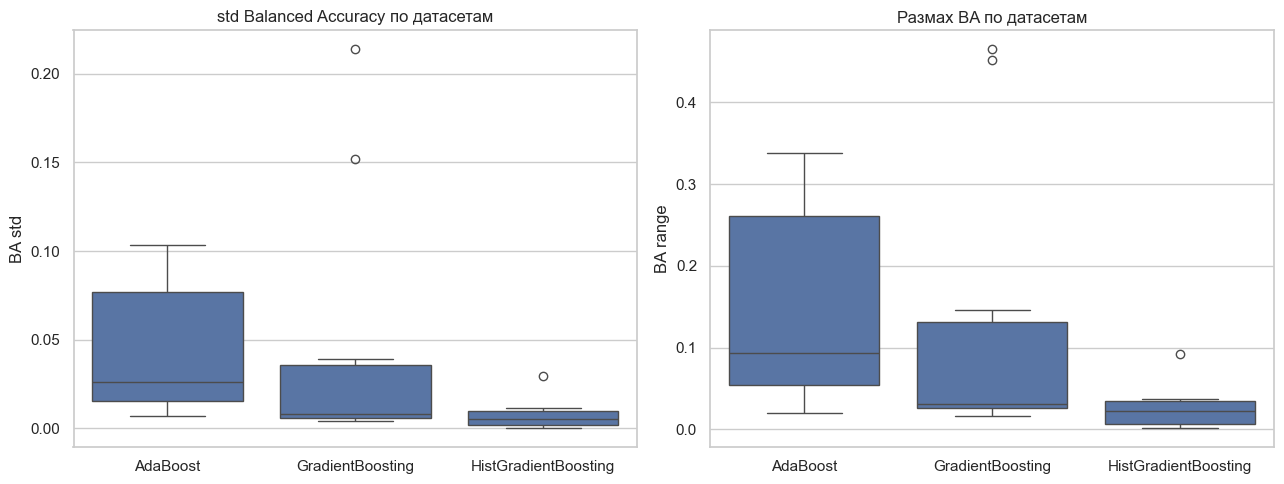

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=sensitivity_df, x="algorithm", y="BA_std", ax=axes[0])
axes[0].set_title("std Balanced Accuracy по датасетам")
axes[0].set_xlabel("")
axes[0].set_ylabel("BA std")

sns.boxplot(data=sensitivity_df, x="algorithm", y="BA_range", ax=axes[1])
axes[1].set_title("Размах BA по датасетам")
axes[1].set_xlabel("")
axes[1].set_ylabel("BA range")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "scenario6_sensitivity_boxplots.png", dpi=120, bbox_inches="tight")

plt.show()

In [90]:
print("СЦЕНАРИЙ 6 — ИТОГОВЫЕ МЕТРИКИ")

print("\nСредняя чувствительность к гиперпараметрам:")
display(avg_sensitivity.sort_values("mean_regret").round(4))


print("\nBA_std по конфигурациям:")
display(sensitivity_df.pivot(index="dataset", columns="algorithm", values="BA_std").round(4))

print("\nBA_range — разница между лучшей и худшей конфигурацией:")
display(sensitivity_df.pivot(index="dataset", columns="algorithm", values="BA_range").round(4))

print("\nmean_regret — средняя потеря относительно лучшей конфигурации:")
display(sensitivity_df.pivot(index="dataset", columns="algorithm", values="mean_regret").round(4))

print("\nНаиболее нестабильные случаи по mean_regret:")
res = sensitivity_df.sort_values("mean_regret", ascending=False)[["dataset", "size_group", "algorithm", "mean_regret", "BA_std", "BA_range", "rel_density",]]
res.head(10).round(4)

СЦЕНАРИЙ 6 — ИТОГОВЫЕ МЕТРИКИ

Средняя чувствительность к гиперпараметрам:


,algorithm,mean_BA_std,mean_BA_range,rel_density,mean_regret
2,HistGradientBoosting,0.0078,0.0269,0.2701,0.0113
1,GradientBoosting,0.0470,0.1303,0.2909,0.0533
0,AdaBoost,0.0442,0.1477,0.2982,0.0639



BA_std по конфигурациям:


algorithm,AdaBoost,GradientBoosting,HistGradientBoosting
dataset,,,
adult,0.0144,0.0041,0.0012
breast_cancer,0.0179,0.2138,0.0115
digits,0.0808,0.0070,0.0055
jannis,0.0324,0.0265,0.0042
kick,0.0069,0.0065,0.0009
phoneme,0.0200,0.0093,0.0105
secondary_mushroom,0.0949,0.0390,0.0003
spambase,0.0072,0.0059,0.0056
steel_plates,0.0642,0.0059,0.0088



BA_range — разница между лучшей и худшей конфигурацией:


algorithm,AdaBoost,GradientBoosting,HistGradientBoosting
dataset,,,
adult,0.0525,0.0162,0.0043
breast_cancer,0.0578,0.4517,0.0334
digits,0.2733,0.0268,0.0228
jannis,0.1160,0.0896,0.0152
kick,0.0197,0.0256,0.0038
phoneme,0.0714,0.0340,0.0376
secondary_mushroom,0.3388,0.1460,0.0017
spambase,0.0258,0.0225,0.0223
steel_plates,0.2259,0.0255,0.0358



mean_regret — средняя потеря относительно лучшей конфигурации:


algorithm,AdaBoost,GradientBoosting,HistGradientBoosting
dataset,,,
adult,0.0156,0.0049,0.0017
breast_cancer,0.0238,0.2719,0.0180
digits,0.0713,0.0099,0.0073
jannis,0.0356,0.0233,0.0056
kick,0.0092,0.0095,0.0017
phoneme,0.0311,0.0133,0.0154
secondary_mushroom,0.2224,0.0234,0.0001
spambase,0.0103,0.0090,0.0090
steel_plates,0.0789,0.0083,0.0132



Наиболее нестабильные случаи по mean_regret:


,dataset,size_group,algorithm,mean_regret,BA_std,BA_range,rel_density
4,breast_cancer,small,GradientBoosting,0.2719,0.2138,0.4517,0.4733
18,secondary_mushroom,large,AdaBoost,0.2224,0.0949,0.3388,0.2801
28,vehicle,small,GradientBoosting,0.1592,0.1521,0.4650,0.3272
27,vehicle,small,AdaBoost,0.1409,0.1032,0.2958,0.3490
24,steel_plates,medium,AdaBoost,0.0789,0.0642,0.2259,0.2844
6,digits,medium,AdaBoost,0.0713,0.0808,0.2733,0.2958
29,vehicle,small,HistGradientBoosting,0.0412,0.0294,0.0925,0.3180
9,jannis,large,AdaBoost,0.0356,0.0324,0.1160,0.2794
15,phoneme,medium,AdaBoost,0.0311,0.0200,0.0714,0.2806
3,breast_cancer,small,AdaBoost,0.0238,0.0179,0.0578,0.3090
